#  Análisis Exploratorio de Datos (EDA) — Clasificación
## Dataset: Rotación de Empleados (IBM HR Analytics)
---

##  Importación de librerías y carga del dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Estilo general
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

DB_PATH = Path().resolve().parent / "data" / "raw" / "dataset_clasificacion.csv"

df_raw = pd.read_csv(DB_PATH)
print(f"Dimensiones originales: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

Dimensiones originales: 1470 filas × 35 columnas


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


---
## 1. Limpieza de Datos
> Se normalizan textos a minúsculas, se eliminan espacios y caracteres extraños,
> y se verifica la presencia de datos faltantes.

In [2]:
df = df_raw.copy()

# 1-A: Convertir todas las columnas de texto a minúsculas y limpiar espacios
str_cols = df.select_dtypes(include='object').columns.tolist()
for col in str_cols:
    df[col] = (df[col]
               .astype(str)
               .str.strip()
               .str.lower()
               .str.replace(r'[^a-z0-9 _&\-]', '', regex=True))

print("=== Columnas de texto normalizadas ===")
for col in str_cols:
    print(f"  {col}: {df[col].unique().tolist()}")

=== Columnas de texto normalizadas ===
  Attrition: ['yes', 'no']
  BusinessTravel: ['travel_rarely', 'travel_frequently', 'non-travel']
  Department: ['sales', 'research & development', 'human resources']
  EducationField: ['life sciences', 'other', 'medical', 'marketing', 'technical degree', 'human resources']
  Gender: ['female', 'male']
  JobRole: ['sales executive', 'research scientist', 'laboratory technician', 'manufacturing director', 'healthcare representative', 'manager', 'sales representative', 'research director', 'human resources']
  MaritalStatus: ['single', 'married', 'divorced']
  Over18: ['y']
  OverTime: ['yes', 'no']


In [3]:
# 1-B: Datos faltantes
print("=== Datos faltantes por columna ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0]

if missing_df.empty:
    print("  No se encontraron datos faltantes en ninguna columna.")
else:
    print(missing_df)

=== Datos faltantes por columna ===
  No se encontraron datos faltantes en ninguna columna.


In [4]:
# 1-C: Columnas constantes (sin variabilidad — candidatas a eliminar)
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print(f"Columnas con un único valor (constantes): {constant_cols}")
print(" 'EmployeeCount', 'Over18' y 'StandardHours' no aportan información.")
print(" Se conservan para registro; se excluirán del análisis donde no apliquen.")

Columnas con un único valor (constantes): ['EmployeeCount', 'Over18', 'StandardHours']
 'EmployeeCount', 'Over18' y 'StandardHours' no aportan información.
 Se conservan para registro; se excluirán del análisis donde no apliquen.


---
## 2. Identificación del Tipo de Variables
Las variables se clasifican en **numéricas continuas**, **numéricas discretas / ordinales** y **categóricas nominales**.  
Las unidades monetarias están expresadas en **dólares (USD)**.

In [5]:
variable_info = {
    # Variable                  : (Tipo,            Unidad / Escala)
    'Age'                       : ('Numérica continua',    'años'),
    'Attrition'                 : ('Categórica nominal',   'yes / no'),
    'BusinessTravel'            : ('Categórica nominal',   'frecuencia de viaje'),
    'DailyRate'                 : ('Numérica continua',    'USD / día'),
    'Department'                : ('Categórica nominal',   'departamento'),
    'DistanceFromHome'          : ('Numérica continua',    'km'),
    'Education'                 : ('Numérica ordinal',     '1=Below College … 5=Doctor'),
    'EducationField'            : ('Categórica nominal',   'campo de estudio'),
    'EmployeeCount'             : ('Constante',            'siempre = 1'),
    'EmployeeNumber'            : ('Identificador',        'ID único'),
    'EnvironmentSatisfaction'   : ('Numérica ordinal',     '1=Low … 4=Very High'),
    'Gender'                    : ('Categórica nominal',   'female / male'),
    'HourlyRate'                : ('Numérica continua',    'USD / hora'),
    'JobInvolvement'            : ('Numérica ordinal',     '1=Low … 4=Very High'),
    'JobLevel'                  : ('Numérica ordinal',     '1=Entry … 5=C-Level'),
    'JobRole'                   : ('Categórica nominal',   'rol / cargo'),
    'JobSatisfaction'           : ('Numérica ordinal',     '1=Low … 4=Very High'),
    'MaritalStatus'             : ('Categórica nominal',   'single / married / divorced'),
    'MonthlyIncome'             : ('Numérica continua',    'USD / mes'),
    'MonthlyRate'               : ('Numérica continua',    'USD / mes'),
    'NumCompaniesWorked'        : ('Numérica discreta',    'número de empresas'),
    'Over18'                    : ('Constante',            'siempre = y'),
    'OverTime'                  : ('Categórica nominal',   'yes / no'),
    'PercentSalaryHike'         : ('Numérica continua',    '% de aumento salarial'),
    'PerformanceRating'         : ('Numérica ordinal',     '1=Low … 4=Outstanding'),
    'RelationshipSatisfaction'  : ('Numérica ordinal',     '1=Low … 4=Very High'),
    'StandardHours'             : ('Constante',            'siempre = 80 h'),
    'StockOptionLevel'          : ('Numérica ordinal',     '0=None … 3=High'),
    'TotalWorkingYears'         : ('Numérica continua',    'años'),
    'TrainingTimesLastYear'     : ('Numérica discreta',    'nº de capacitaciones'),
    'WorkLifeBalance'           : ('Numérica ordinal',     '1=Bad … 4=Best'),
    'YearsAtCompany'            : ('Numérica continua',    'años en la empresa'),
    'YearsInCurrentRole'        : ('Numérica continua',    'años en el rol actual'),
    'YearsSinceLastPromotion'   : ('Numérica continua',    'años desde última promoción'),
    'YearsWithCurrManager'      : ('Numérica continua',    'años con el manager actual'),
}

info_df = pd.DataFrame.from_dict(variable_info, orient='index',
                                  columns=['Tipo de Variable', 'Unidad / Escala'])
info_df.index.name = 'Variable'
print(info_df.to_string())

                            Tipo de Variable              Unidad / Escala
Variable                                                                 
Age                        Numérica continua                         años
Attrition                 Categórica nominal                     yes / no
BusinessTravel            Categórica nominal          frecuencia de viaje
DailyRate                  Numérica continua                    USD / día
Department                Categórica nominal                 departamento
DistanceFromHome           Numérica continua                           km
Education                   Numérica ordinal   1=Below College … 5=Doctor
EducationField            Categórica nominal             campo de estudio
EmployeeCount                      Constante                  siempre = 1
EmployeeNumber                 Identificador                     ID único
EnvironmentSatisfaction     Numérica ordinal          1=Low … 4=Very High
Gender                    Categórica n

In [6]:
# Resumen de conteos por tipo
tipo_counts = info_df['Tipo de Variable'].value_counts()
print("\n=== Conteo por tipo ===")
print(tipo_counts.to_string())


=== Conteo por tipo ===
Tipo de Variable
Numérica continua     12
Numérica ordinal       9
Categórica nominal     8
Constante              3
Numérica discreta      2
Identificador          1


---
## 3. Análisis Descriptivo
### 3.1 Estadísticas: media, mediana y desviación estándar

In [7]:
num_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]
ord_cols = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'WorkLifeBalance'
]

desc = df[num_cols + ord_cols].agg(['mean', 'median', 'std']).T
desc.columns = ['Media', 'Mediana', 'Desv. Estándar']
desc = desc.round(2)
desc.index.name = 'Variable'
print(desc.to_string())

                             Media  Mediana  Desv. Estándar
Variable                                                   
Age                          36.92     36.0            9.14
DailyRate                   802.49    802.0          403.51
DistanceFromHome              9.19      7.0            8.11
HourlyRate                   65.89     66.0           20.33
MonthlyIncome              6502.93   4919.0         4707.96
MonthlyRate               14313.10  14235.5         7117.79
NumCompaniesWorked            2.69      2.0            2.50
PercentSalaryHike            15.21     14.0            3.66
TotalWorkingYears            11.28     10.0            7.78
TrainingTimesLastYear         2.80      3.0            1.29
YearsAtCompany                7.01      5.0            6.13
YearsInCurrentRole            4.23      3.0            3.62
YearsSinceLastPromotion       2.19      1.0            3.22
YearsWithCurrManager          4.12      3.0            3.57
Education                     2.91      

### 3.2 Distribuciones — Variables Numéricas Continuas (Histogramas)

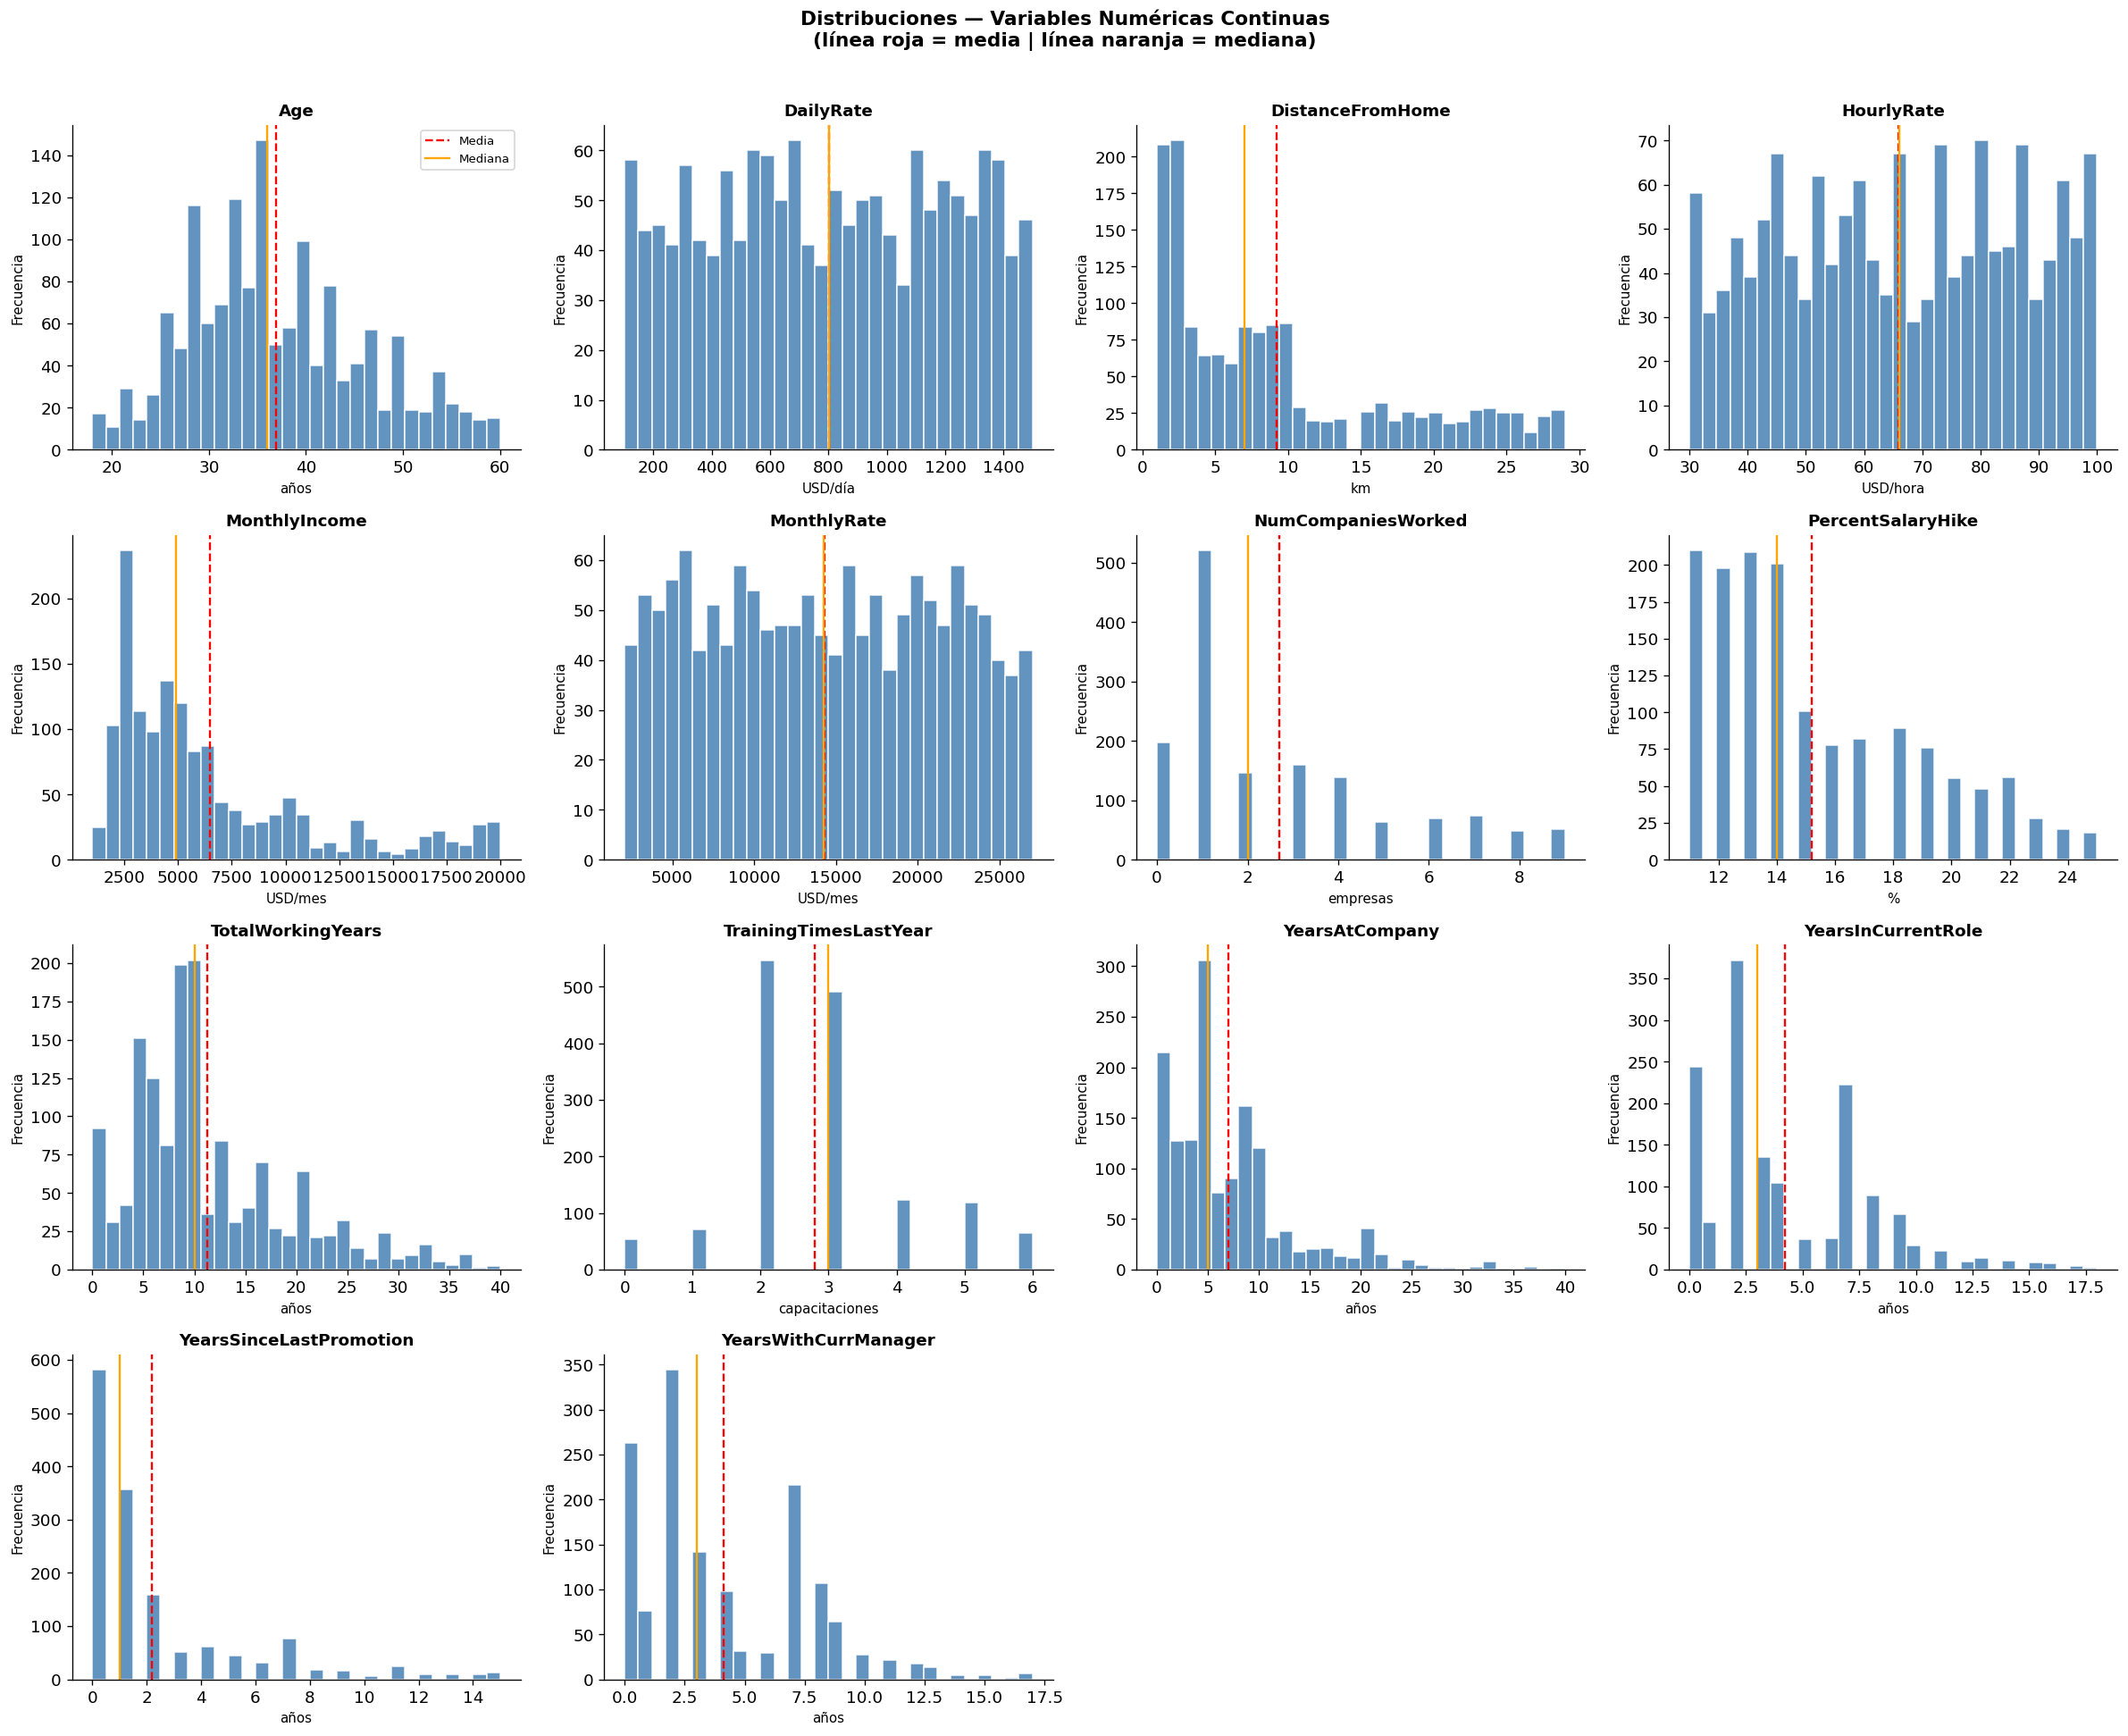

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

units = {
    'Age': 'años', 'DailyRate': 'USD/día', 'DistanceFromHome': 'km',
    'HourlyRate': 'USD/hora', 'MonthlyIncome': 'USD/mes', 'MonthlyRate': 'USD/mes',
    'NumCompaniesWorked': 'empresas', 'PercentSalaryHike': '%',
    'TotalWorkingYears': 'años', 'TrainingTimesLastYear': 'capacitaciones',
    'YearsAtCompany': 'años', 'YearsInCurrentRole': 'años',
    'YearsSinceLastPromotion': 'años', 'YearsWithCurrManager': 'años',
}

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.4, label='Media')
    ax.axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1.4, label='Mediana')
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel(units.get(col, ''), fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    if i == 0:
        ax.legend(fontsize=8)

# Ocultar ejes sobrantes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuciones — Variables Numéricas Continuas\n(línea roja = media | línea naranja = mediana)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histogramas_continuas.png', bbox_inches='tight')
plt.show()

### 3.3 Distribuciones — Variables Ordinales (Histogramas de frecuencia)

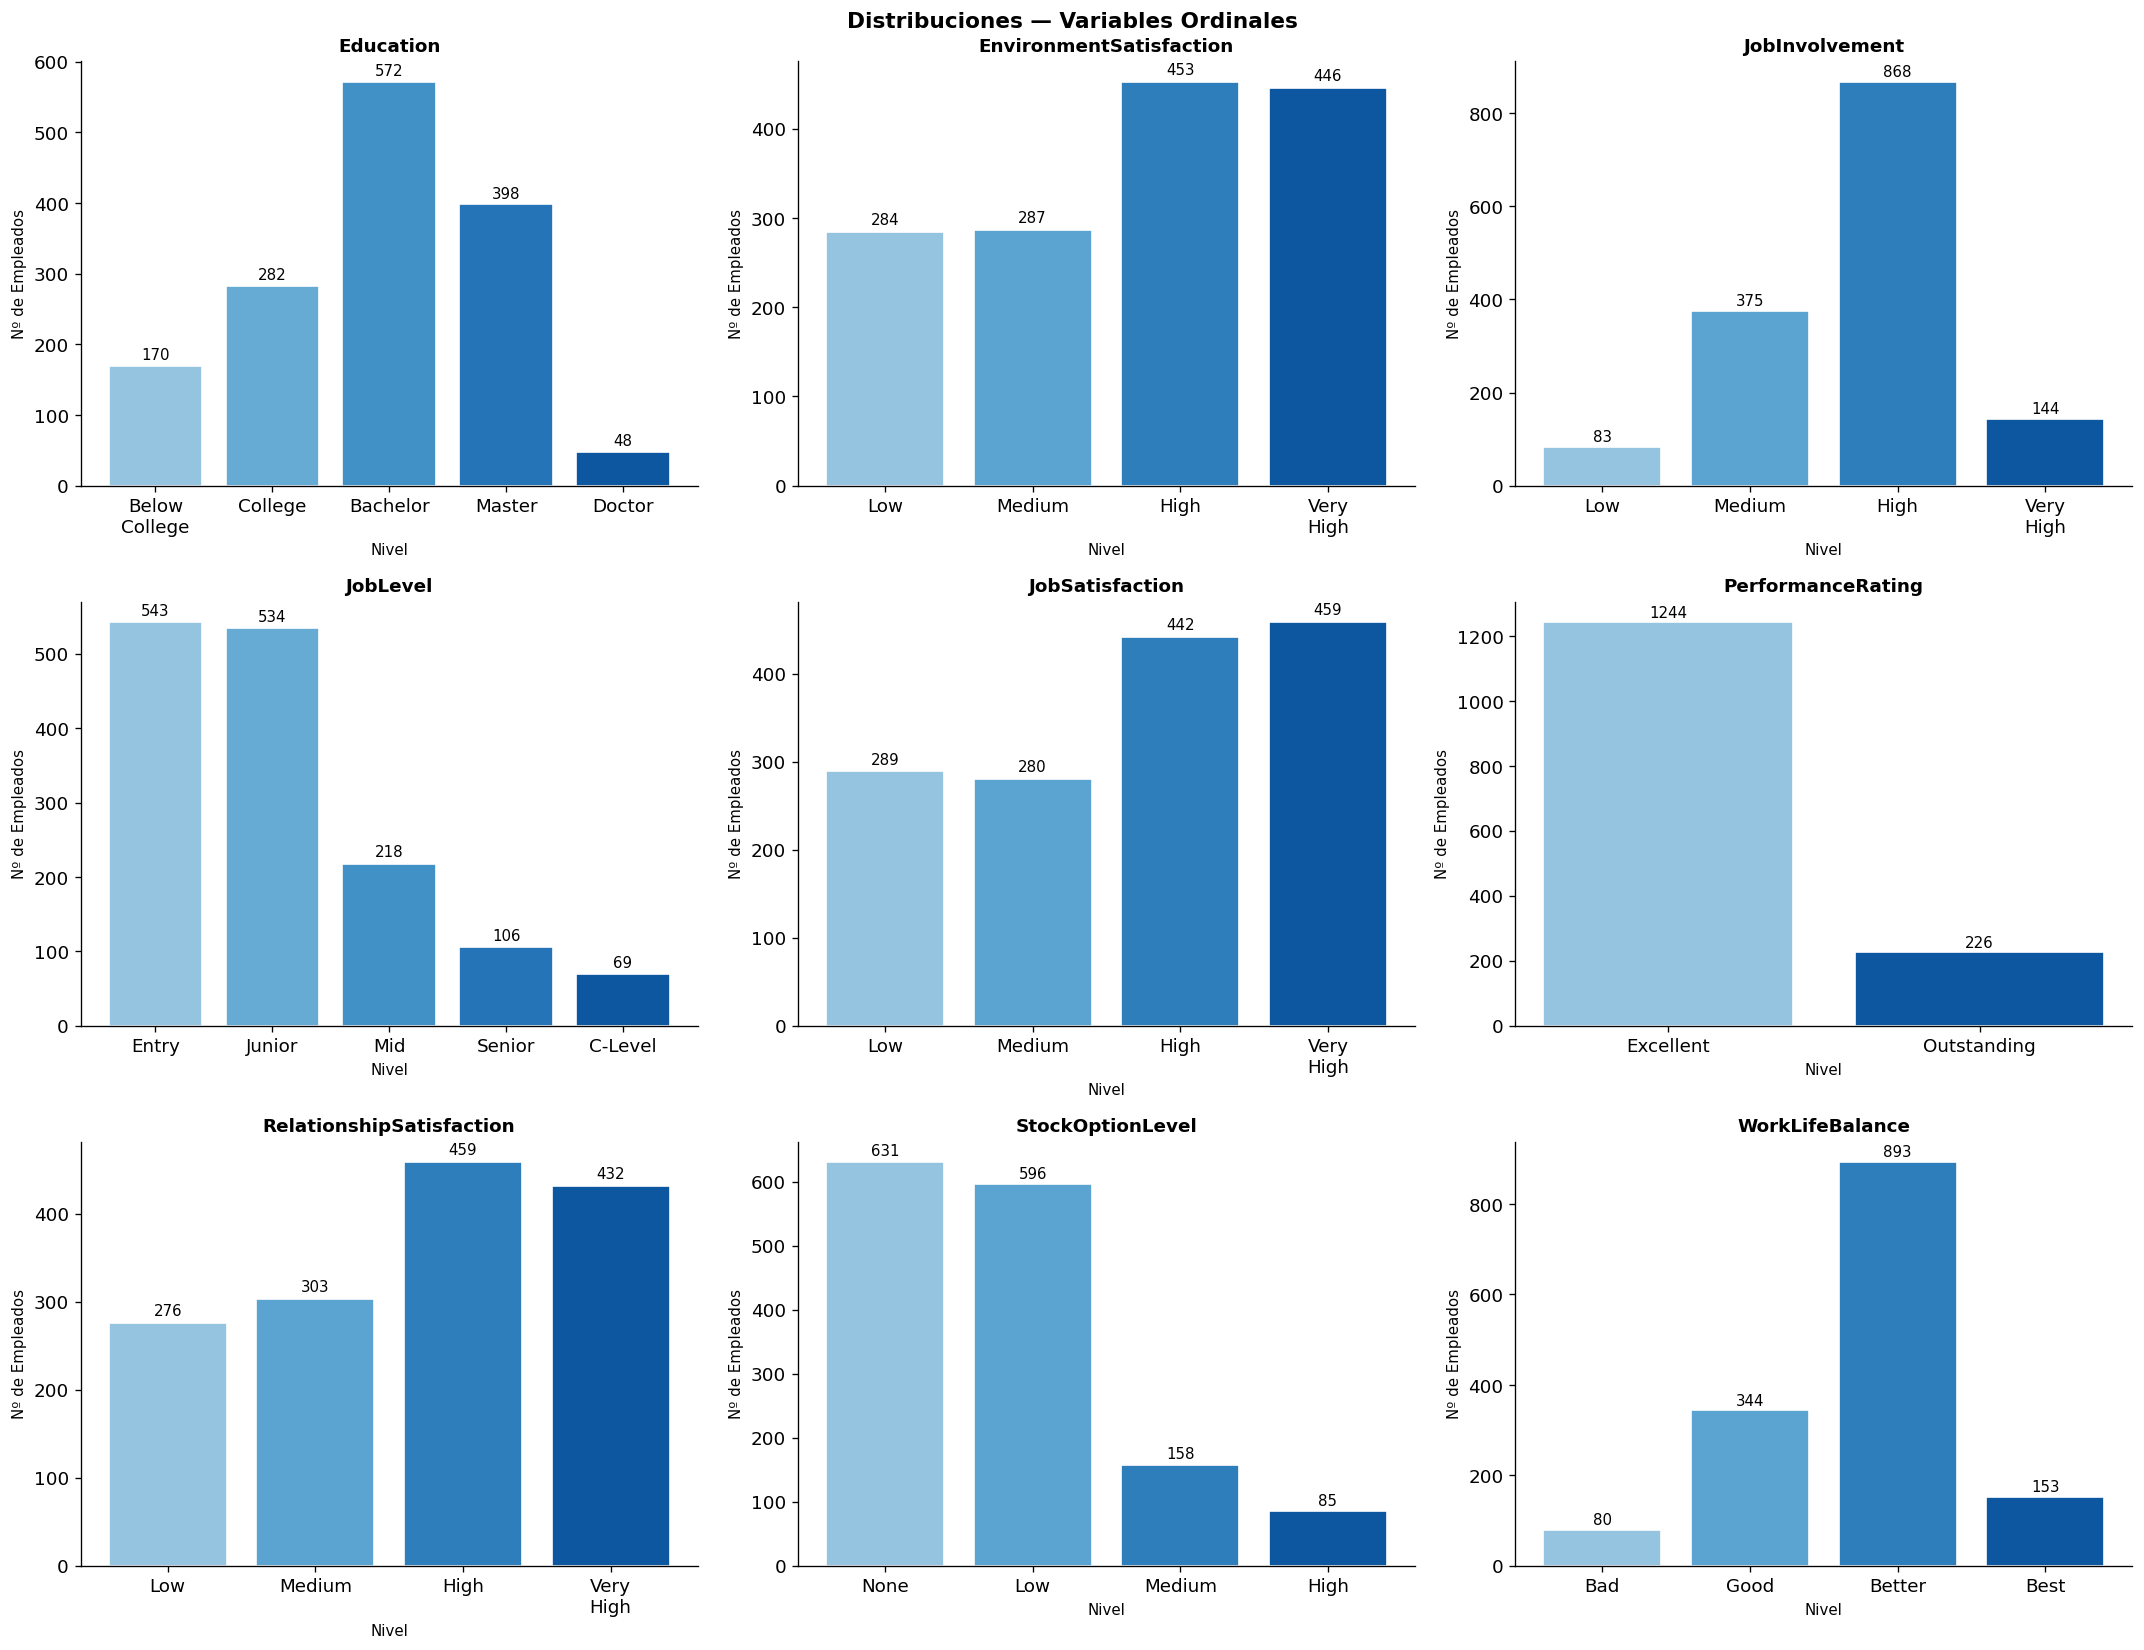

In [9]:
ord_labels = {
    'Education':               {1:'Below\nCollege', 2:'College', 3:'Bachelor', 4:'Master', 5:'Doctor'},
    'EnvironmentSatisfaction': {1:'Low', 2:'Medium', 3:'High', 4:'Very\nHigh'},
    'JobInvolvement':          {1:'Low', 2:'Medium', 3:'High', 4:'Very\nHigh'},
    'JobLevel':                {1:'Entry', 2:'Junior', 3:'Mid', 4:'Senior', 5:'C-Level'},
    'JobSatisfaction':         {1:'Low', 2:'Medium', 3:'High', 4:'Very\nHigh'},
    'PerformanceRating':       {1:'Low', 2:'Good', 3:'Excellent', 4:'Outstanding'},
    'RelationshipSatisfaction':{1:'Low', 2:'Medium', 3:'High', 4:'Very\nHigh'},
    'StockOptionLevel':        {0:'None', 1:'Low', 2:'Medium', 3:'High'},
    'WorkLifeBalance':         {1:'Bad', 2:'Good', 3:'Better', 4:'Best'},
}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(ord_cols):
    ax = axes[i]
    vc = df[col].value_counts().sort_index()
    labels = [ord_labels[col].get(k, str(k)) for k in vc.index]
    colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(vc)))
    bars = ax.bar(labels, vc.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=9)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_ylabel('Nº de Empleados', fontsize=9)
    ax.set_xlabel('Nivel', fontsize=9)

fig.suptitle('Distribuciones — Variables Ordinales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas_ordinales.png', bbox_inches='tight')
plt.show()

### 3.4 Distribuciones — Variables Categóricas Nominales

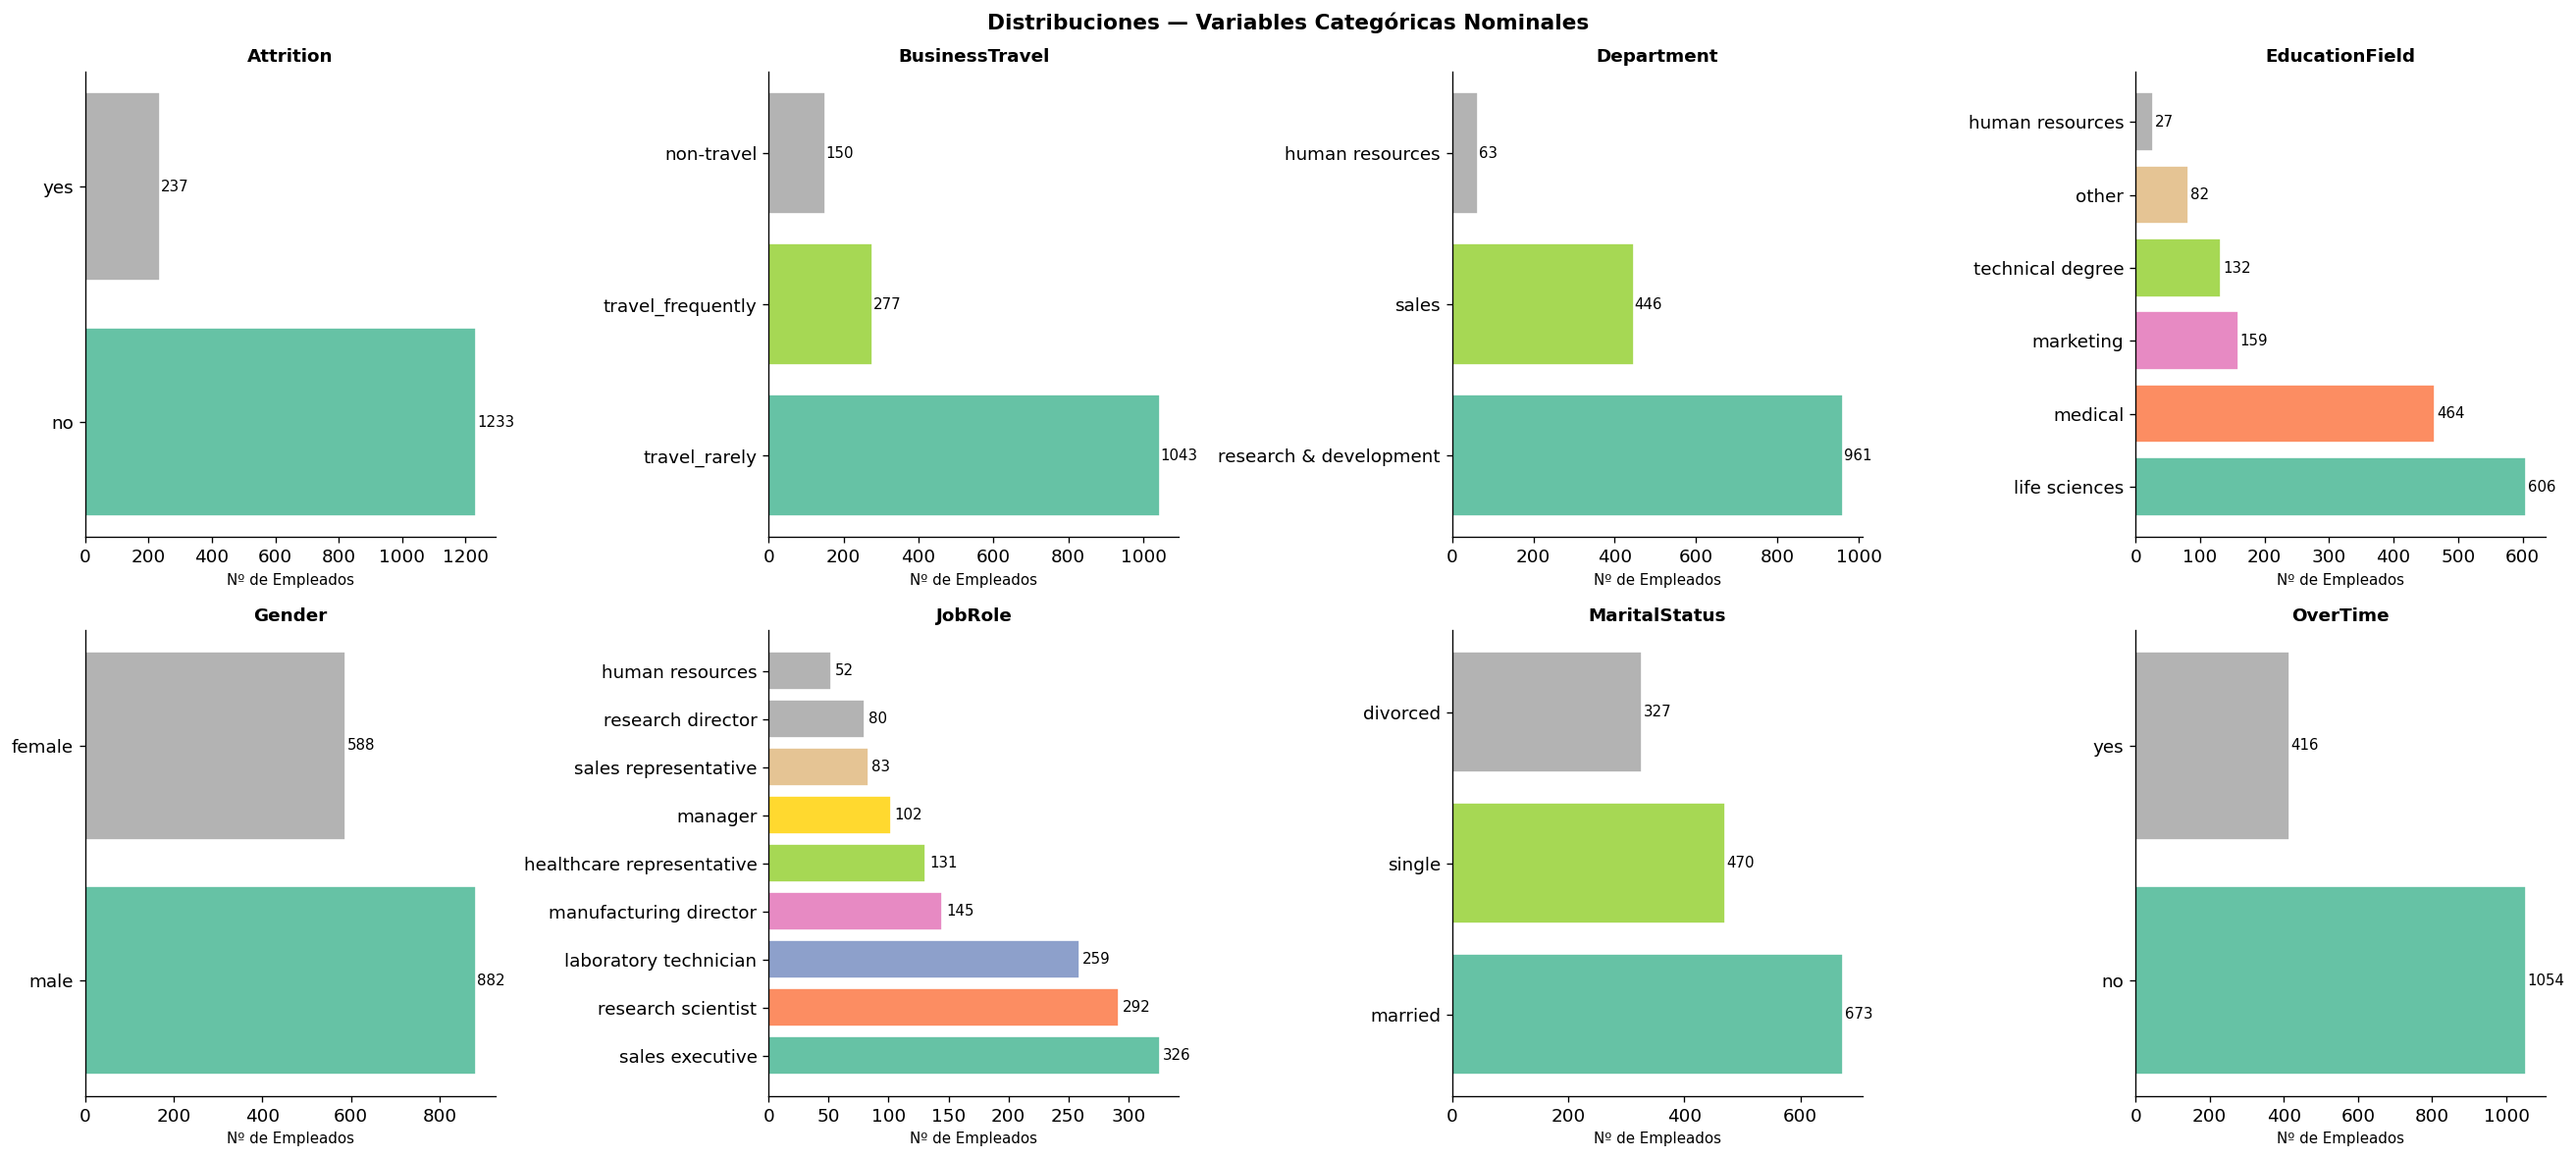

In [11]:
cat_cols = ['Attrition', 'BusinessTravel', 'Department', 'EducationField',
            'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    vc = df[col].value_counts()
    colors = plt.cm.Set2(np.linspace(0, 1, len(vc)))
    bars = ax.barh(vc.index, vc.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('Nº de Empleados', fontsize=9)

fig.suptitle('Distribuciones — Variables Categóricas Nominales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas_categoricas.png', bbox_inches='tight')
plt.show()

---
## 4. Identificación de Valores Atípicos
Se utilizan **boxplots** individuales por variable numérica continua.
Los puntos fuera de los bigotes (1.5 × IQR) son candidatos a valores atípicos.

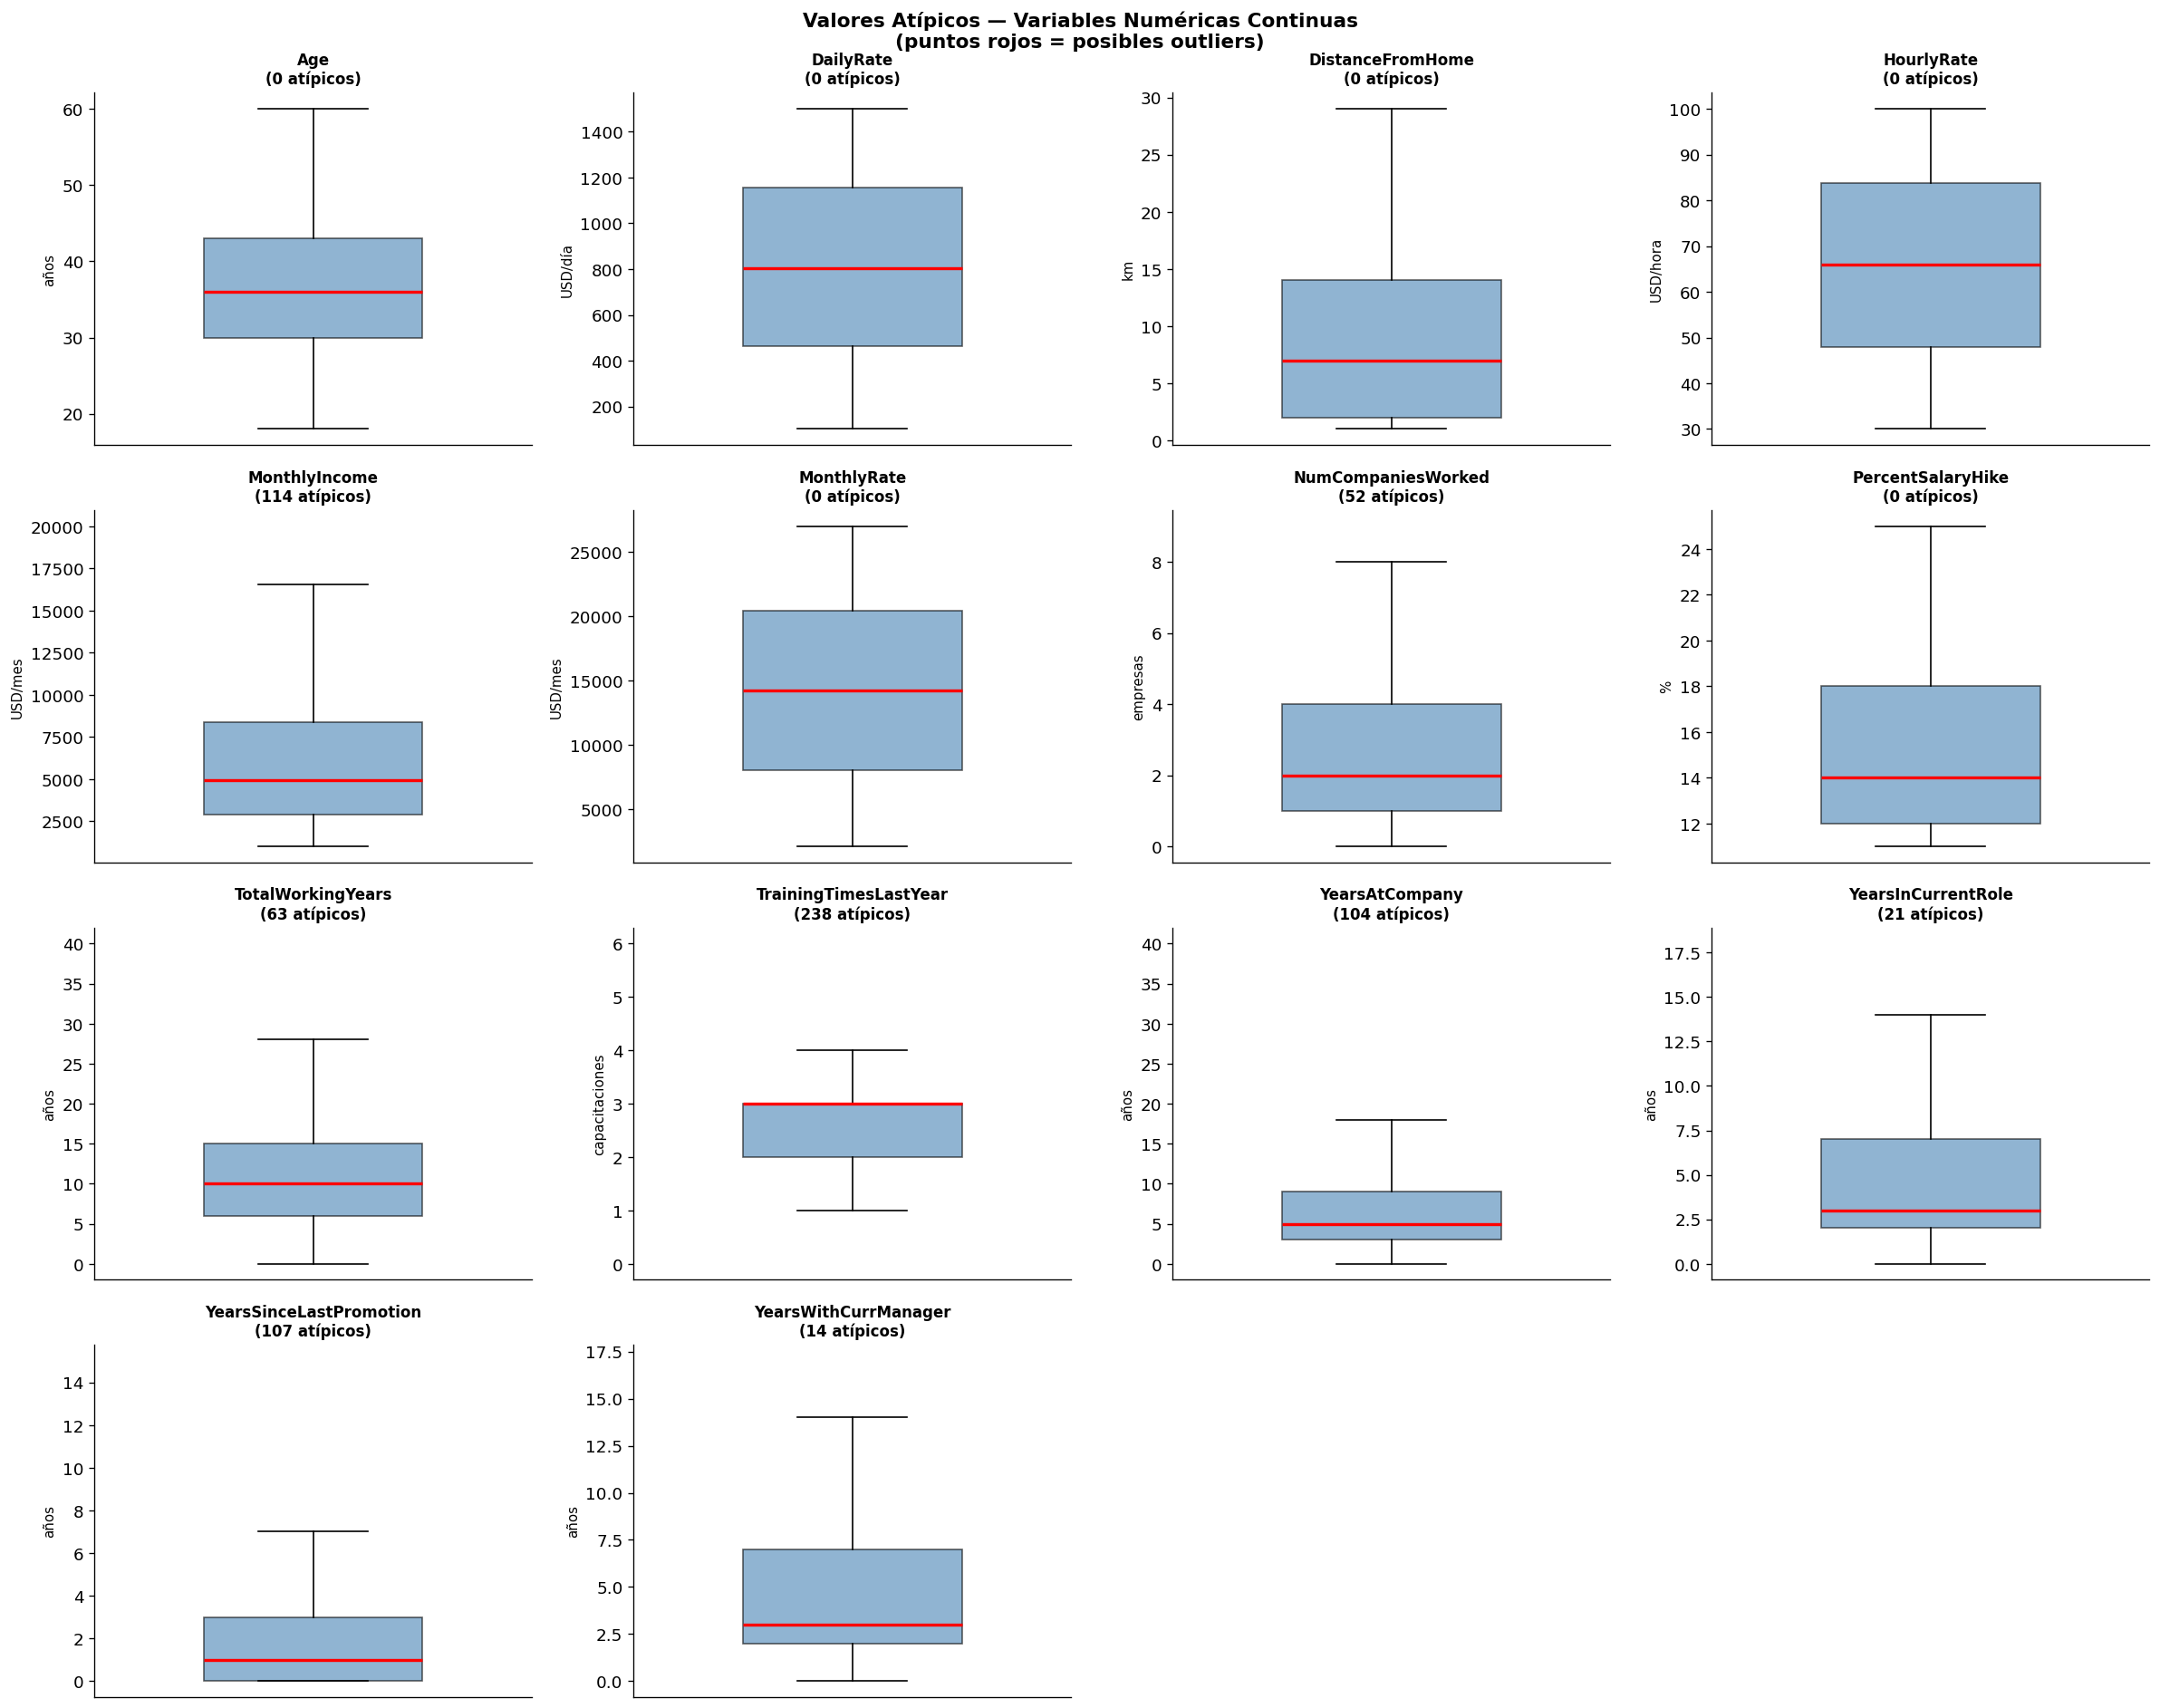

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='tomato', alpha=0.5,
                                    markersize=4, markeredgewidth=0))

    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\n({n_out} atípicos)', fontweight='bold', fontsize=10)
    ax.set_ylabel(units.get(col, ''), fontsize=9)
    ax.set_xticks([])

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Valores Atípicos — Variables Numéricas Continuas\n(puntos rojos = posibles outliers)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_outliers.png', bbox_inches='tight')
plt.show()

In [14]:
# Tabla resumen de outliers por IQR
print(f"{'Variable':<28} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Límite inf':>12} {'Límite sup':>12} {'# Outliers':>12}")
print("-" * 90)
for col in num_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((data < lo) | (data > hi)).sum()
    print(f"{col:<28} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {lo:>12.1f} {hi:>12.1f} {n_out:>12}")

Variable                           Q1       Q3      IQR   Límite inf   Límite sup   # Outliers
------------------------------------------------------------------------------------------
Age                              30.0     43.0     13.0         10.5         62.5            0
DailyRate                       465.0   1157.0    692.0       -573.0       2195.0            0
DistanceFromHome                  2.0     14.0     12.0        -16.0         32.0            0
HourlyRate                       48.0     83.8     35.8         -5.6        137.4            0
MonthlyIncome                  2911.0   8379.0   5468.0      -5291.0      16581.0          114
MonthlyRate                    8047.0  20461.5  12414.5     -10574.8      39083.2            0
NumCompaniesWorked                1.0      4.0      3.0         -3.5          8.5           52
PercentSalaryHike                12.0     18.0      6.0          3.0         27.0            0
TotalWorkingYears                 6.0     15.0      9.

---
## 5. Análisis de Correlación
### 5.1 Mapa de calor — todas las variables numéricas

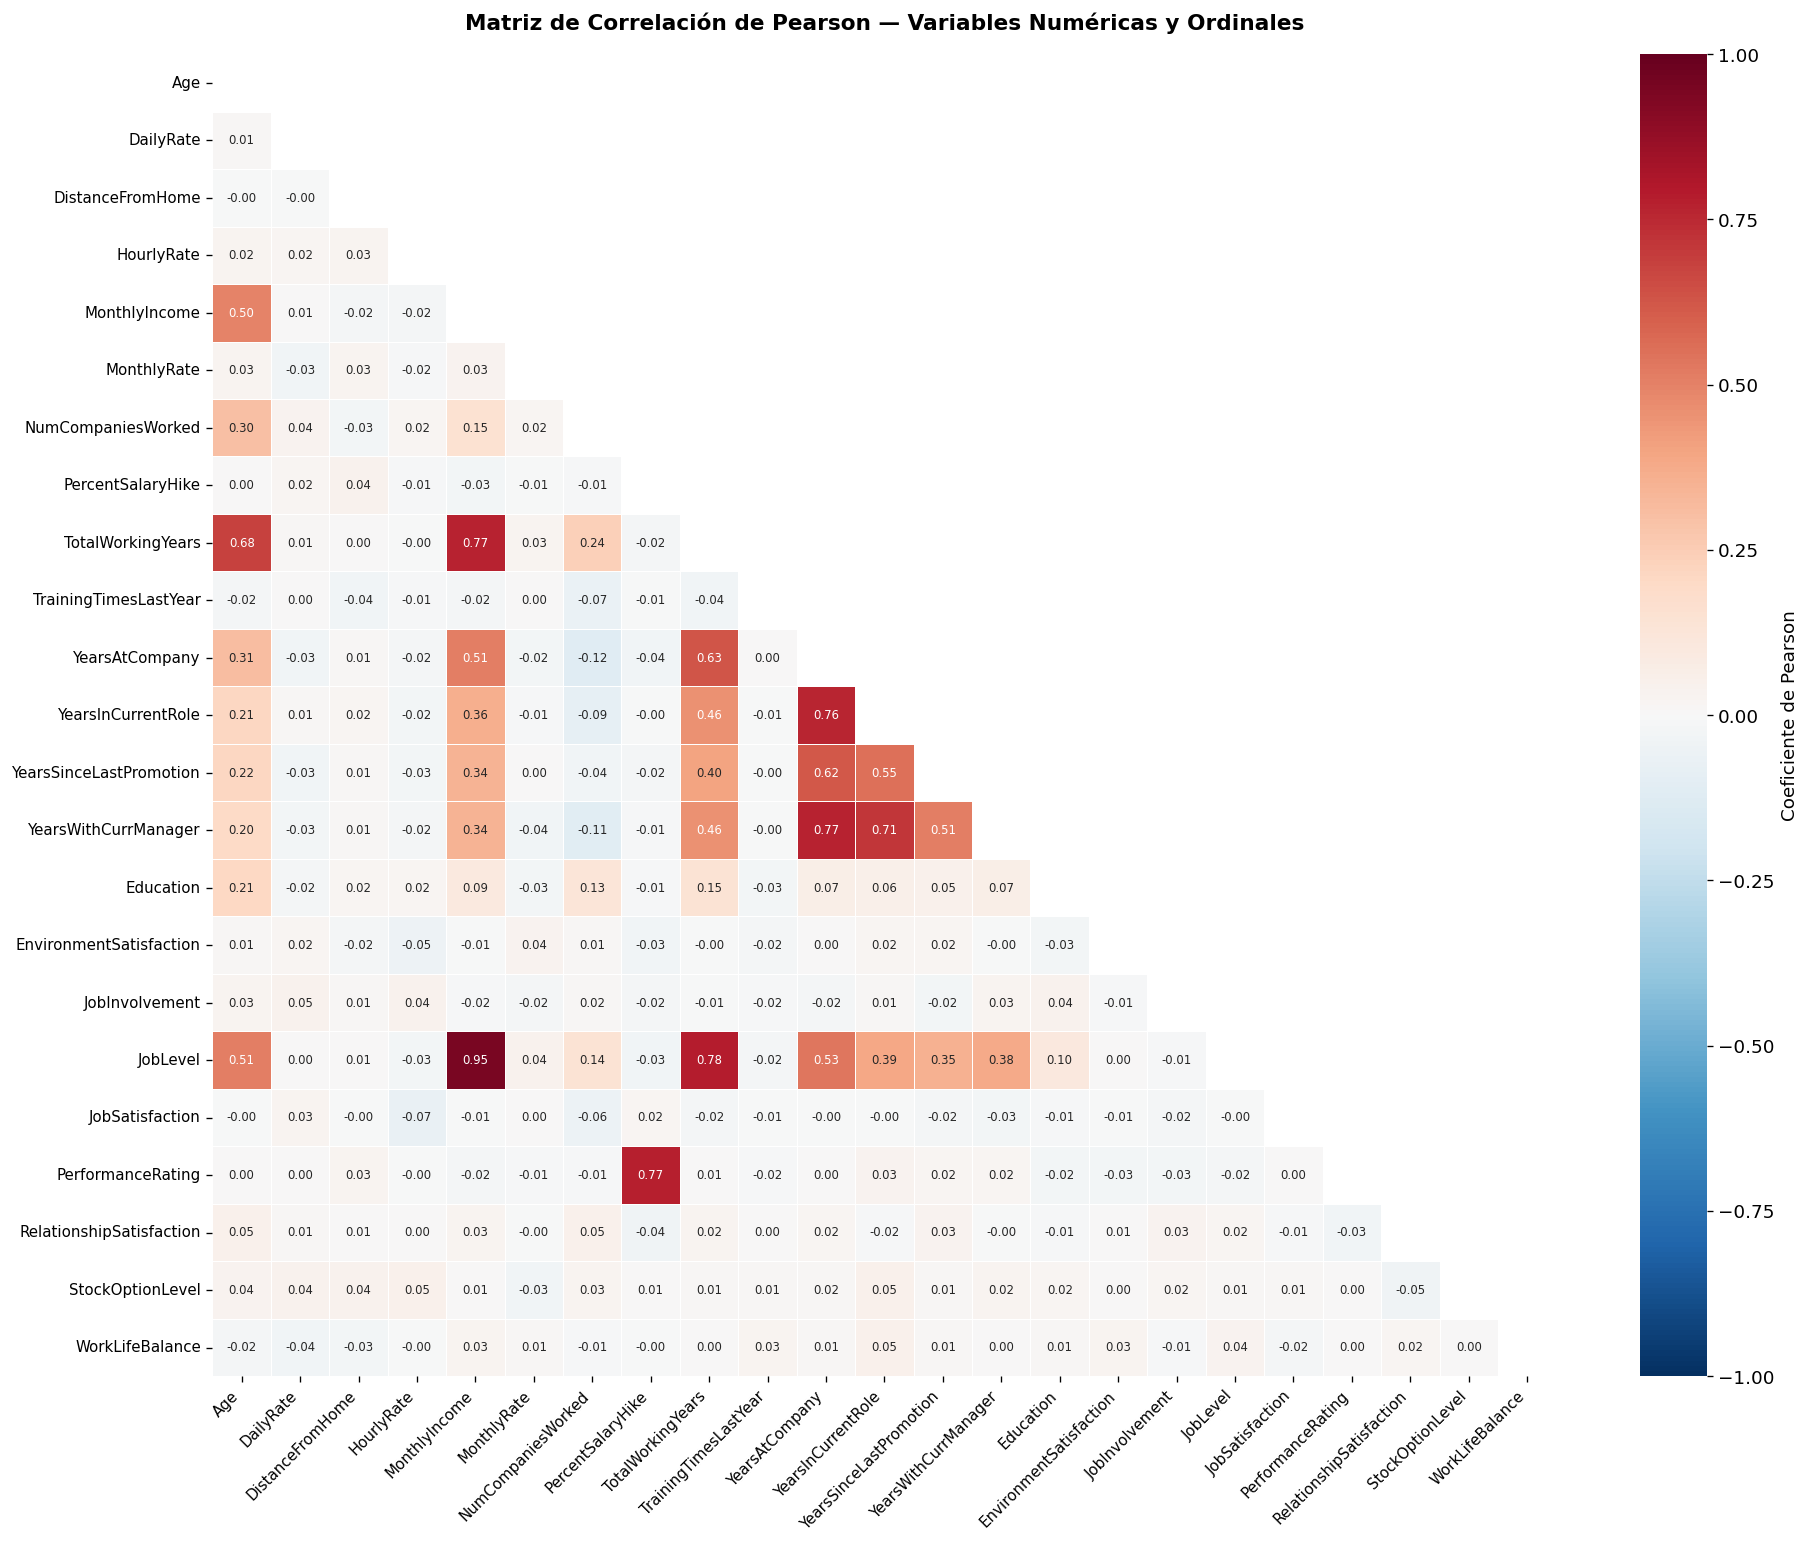

In [23]:
all_num = num_cols + ord_cols
corr = df[all_num].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, linecolor='white',
            annot_kws={'size': 7}, ax=ax,
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de Correlación de Pearson — Variables Numéricas y Ordinales',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlacion_heatmap.png', bbox_inches='tight')
plt.show()

### 5.2 Correspondencia lineal: DailyRate vs MonthlyIncome

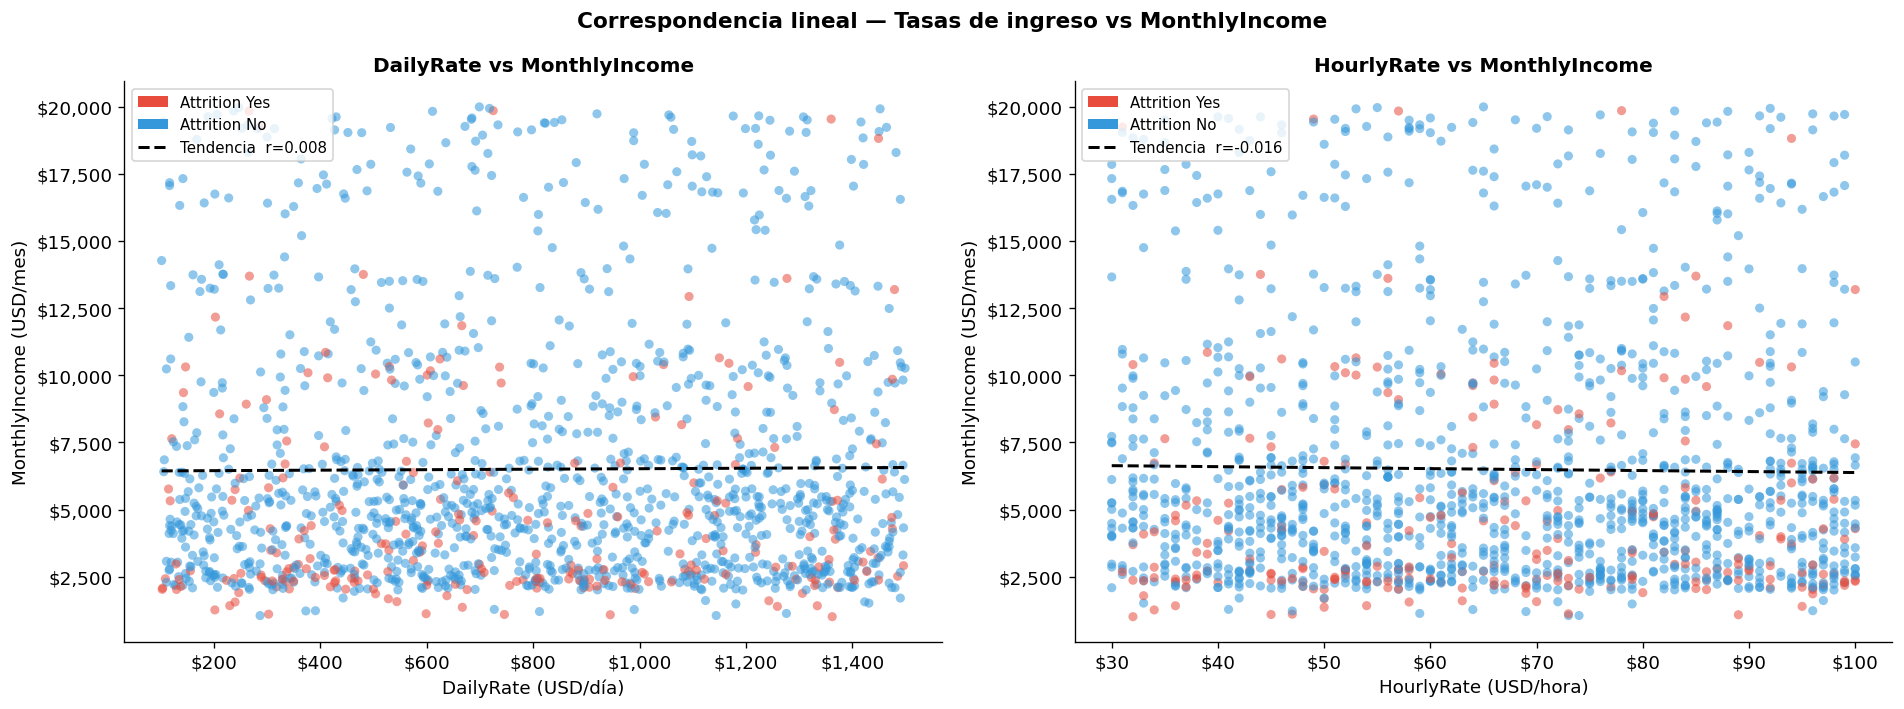


Coeficiente de Pearson  DailyRate  vs MonthlyIncome : r = 0.0077  (p=0.7678)
Coeficiente de Pearson  HourlyRate vs MonthlyIncome : r = -0.0158  (p=0.5451)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — Scatter DailyRate vs MonthlyIncome —
ax = axes[0]
attrition_colors = df['Attrition'].map({'yes': '#e74c3c', 'no': '#3498db'})
scatter = ax.scatter(df['DailyRate'], df['MonthlyIncome'],
                     c=attrition_colors, alpha=0.55, s=30, edgecolors='none')

# Línea de tendencia
m, b, r, p, _ = stats.linregress(df['DailyRate'], df['MonthlyIncome'])
x_line = np.linspace(df['DailyRate'].min(), df['DailyRate'].max(), 200)
ax.plot(x_line, m*x_line + b, color='black', linewidth=1.8,
        linestyle='--', label=f'Tendencia  r={r:.3f}')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Attrition Yes'),
    Patch(facecolor='#3498db', label='Attrition No'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='black',
          linestyle='--', linewidth=1.8, label=f'Tendencia  r={r:.3f}')], fontsize=9)
ax.set_xlabel('DailyRate (USD/día)', fontsize=11)
ax.set_ylabel('MonthlyIncome (USD/mes)', fontsize=11)
ax.set_title('DailyRate vs MonthlyIncome', fontweight='bold', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Scatter HourlyRate vs MonthlyIncome —
ax2 = axes[1]
m2, b2, r2, p2, _ = stats.linregress(df['HourlyRate'], df['MonthlyIncome'])
ax2.scatter(df['HourlyRate'], df['MonthlyIncome'],
            c=attrition_colors, alpha=0.55, s=30, edgecolors='none')
x2 = np.linspace(df['HourlyRate'].min(), df['HourlyRate'].max(), 200)
ax2.plot(x2, m2*x2 + b2, color='black', linewidth=1.8, linestyle='--',
         label=f'Tendencia  r={r2:.3f}')
ax2.legend(handles=legend_elements + [plt.Line2D([0],[0], color='black',
           linestyle='--', linewidth=1.8, label=f'Tendencia  r={r2:.3f}')], fontsize=9)
ax2.set_xlabel('HourlyRate (USD/hora)', fontsize=11)
ax2.set_ylabel('MonthlyIncome (USD/mes)', fontsize=11)
ax2.set_title('HourlyRate vs MonthlyIncome', fontweight='bold', fontsize=12)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.suptitle('Correspondencia lineal — Tasas de ingreso vs MonthlyIncome',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_ingresos_scatter.png', bbox_inches='tight')
plt.show()

print(f"\nCoeficiente de Pearson  DailyRate  vs MonthlyIncome : r = {r:.4f}  (p={p:.4f})")
print(f"Coeficiente de Pearson  HourlyRate vs MonthlyIncome : r = {r2:.4f}  (p={p2:.4f})")

### 5.3 MonthlyRate vs MonthlyIncome

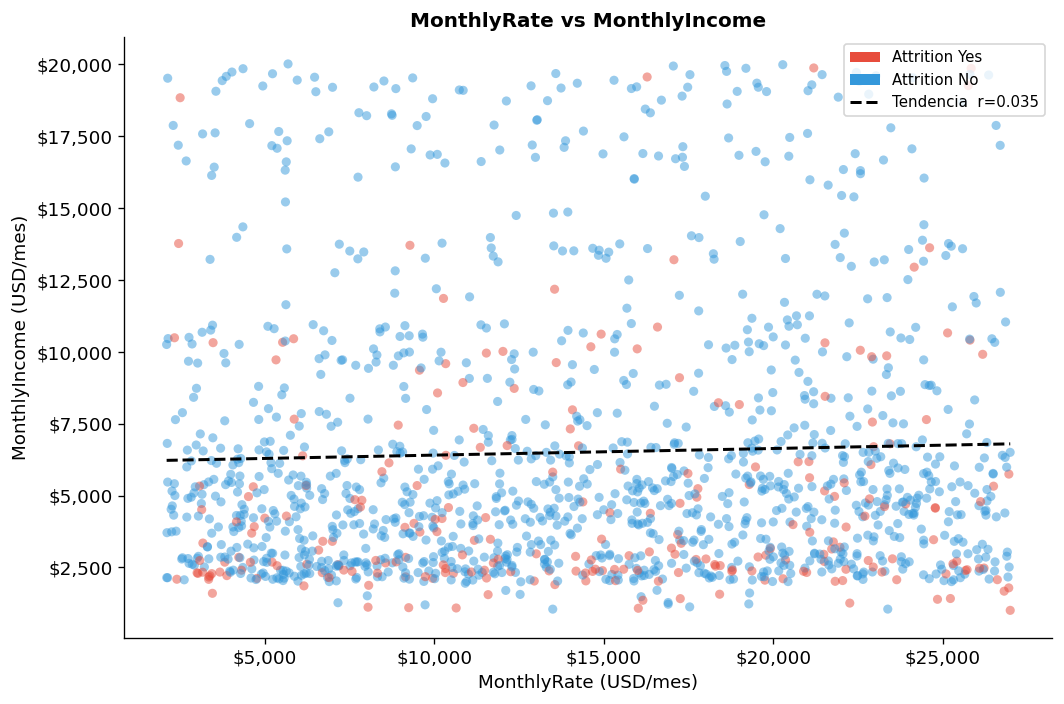

Coeficiente de Pearson  MonthlyRate vs MonthlyIncome : r = 0.0348  (p=0.1822)


In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
m3, b3, r3, p3, _ = stats.linregress(df['MonthlyRate'], df['MonthlyIncome'])
ax.scatter(df['MonthlyRate'], df['MonthlyIncome'],
           c=attrition_colors, alpha=0.5, s=30, edgecolors='none')
x3 = np.linspace(df['MonthlyRate'].min(), df['MonthlyRate'].max(), 200)
ax.plot(x3, m3*x3 + b3, color='black', linewidth=1.8, linestyle='--',
        label=f'Tendencia  r={r3:.3f}')
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='black',
          linestyle='--', linewidth=1.8, label=f'Tendencia  r={r3:.3f}')], fontsize=9)
ax.set_xlabel('MonthlyRate (USD/mes)', fontsize=11)
ax.set_ylabel('MonthlyIncome (USD/mes)', fontsize=11)
ax.set_title('MonthlyRate vs MonthlyIncome', fontweight='bold', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('correlacion_monthlyrate_vs_income.png', bbox_inches='tight')
plt.show()

print(f"Coeficiente de Pearson  MonthlyRate vs MonthlyIncome : r = {r3:.4f}  (p={p3:.4f})")

---
## 6. Análisis de Relaciones entre Variables — Boxplots
Se muestra la distribución de las principales variables numéricas desagregadas
por las categorías más relevantes del dataset.

### 6.1 Variables de ingreso por Attrition

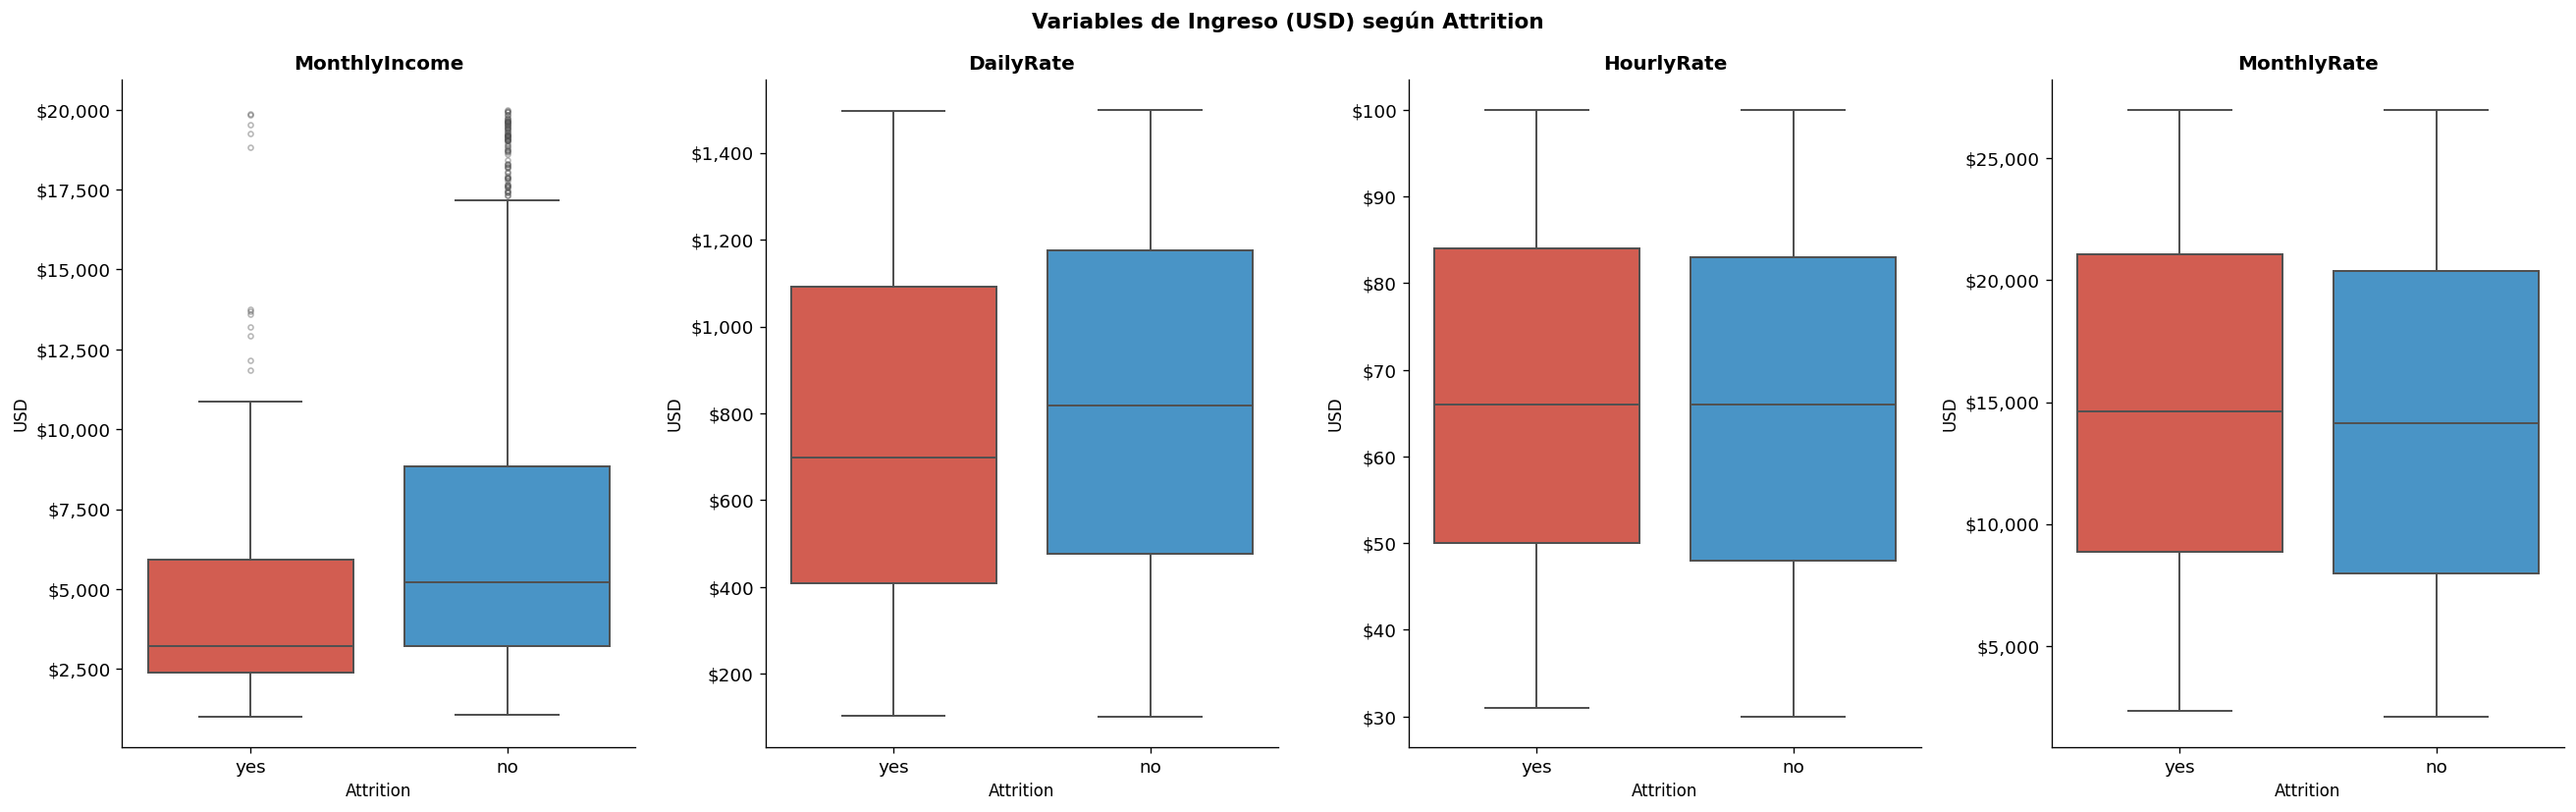

In [17]:
income_vars = ['MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate']
fig, axes = plt.subplots(1, 4, figsize=(22, 7))

palette = {'yes': '#e74c3c', 'no': '#3498db'}
for i, col in enumerate(income_vars):
    ax = axes[i]
    sns.boxplot(data=df, x='Attrition', y=col, palette=palette,
                order=['yes', 'no'], ax=ax, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_xlabel('Attrition', fontsize=10)
    ax.set_ylabel('USD', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.suptitle('Variables de Ingreso (USD) según Attrition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_ingresos_attrition.png', bbox_inches='tight')
plt.show()

### 6.2 Edad y años de experiencia por Attrition

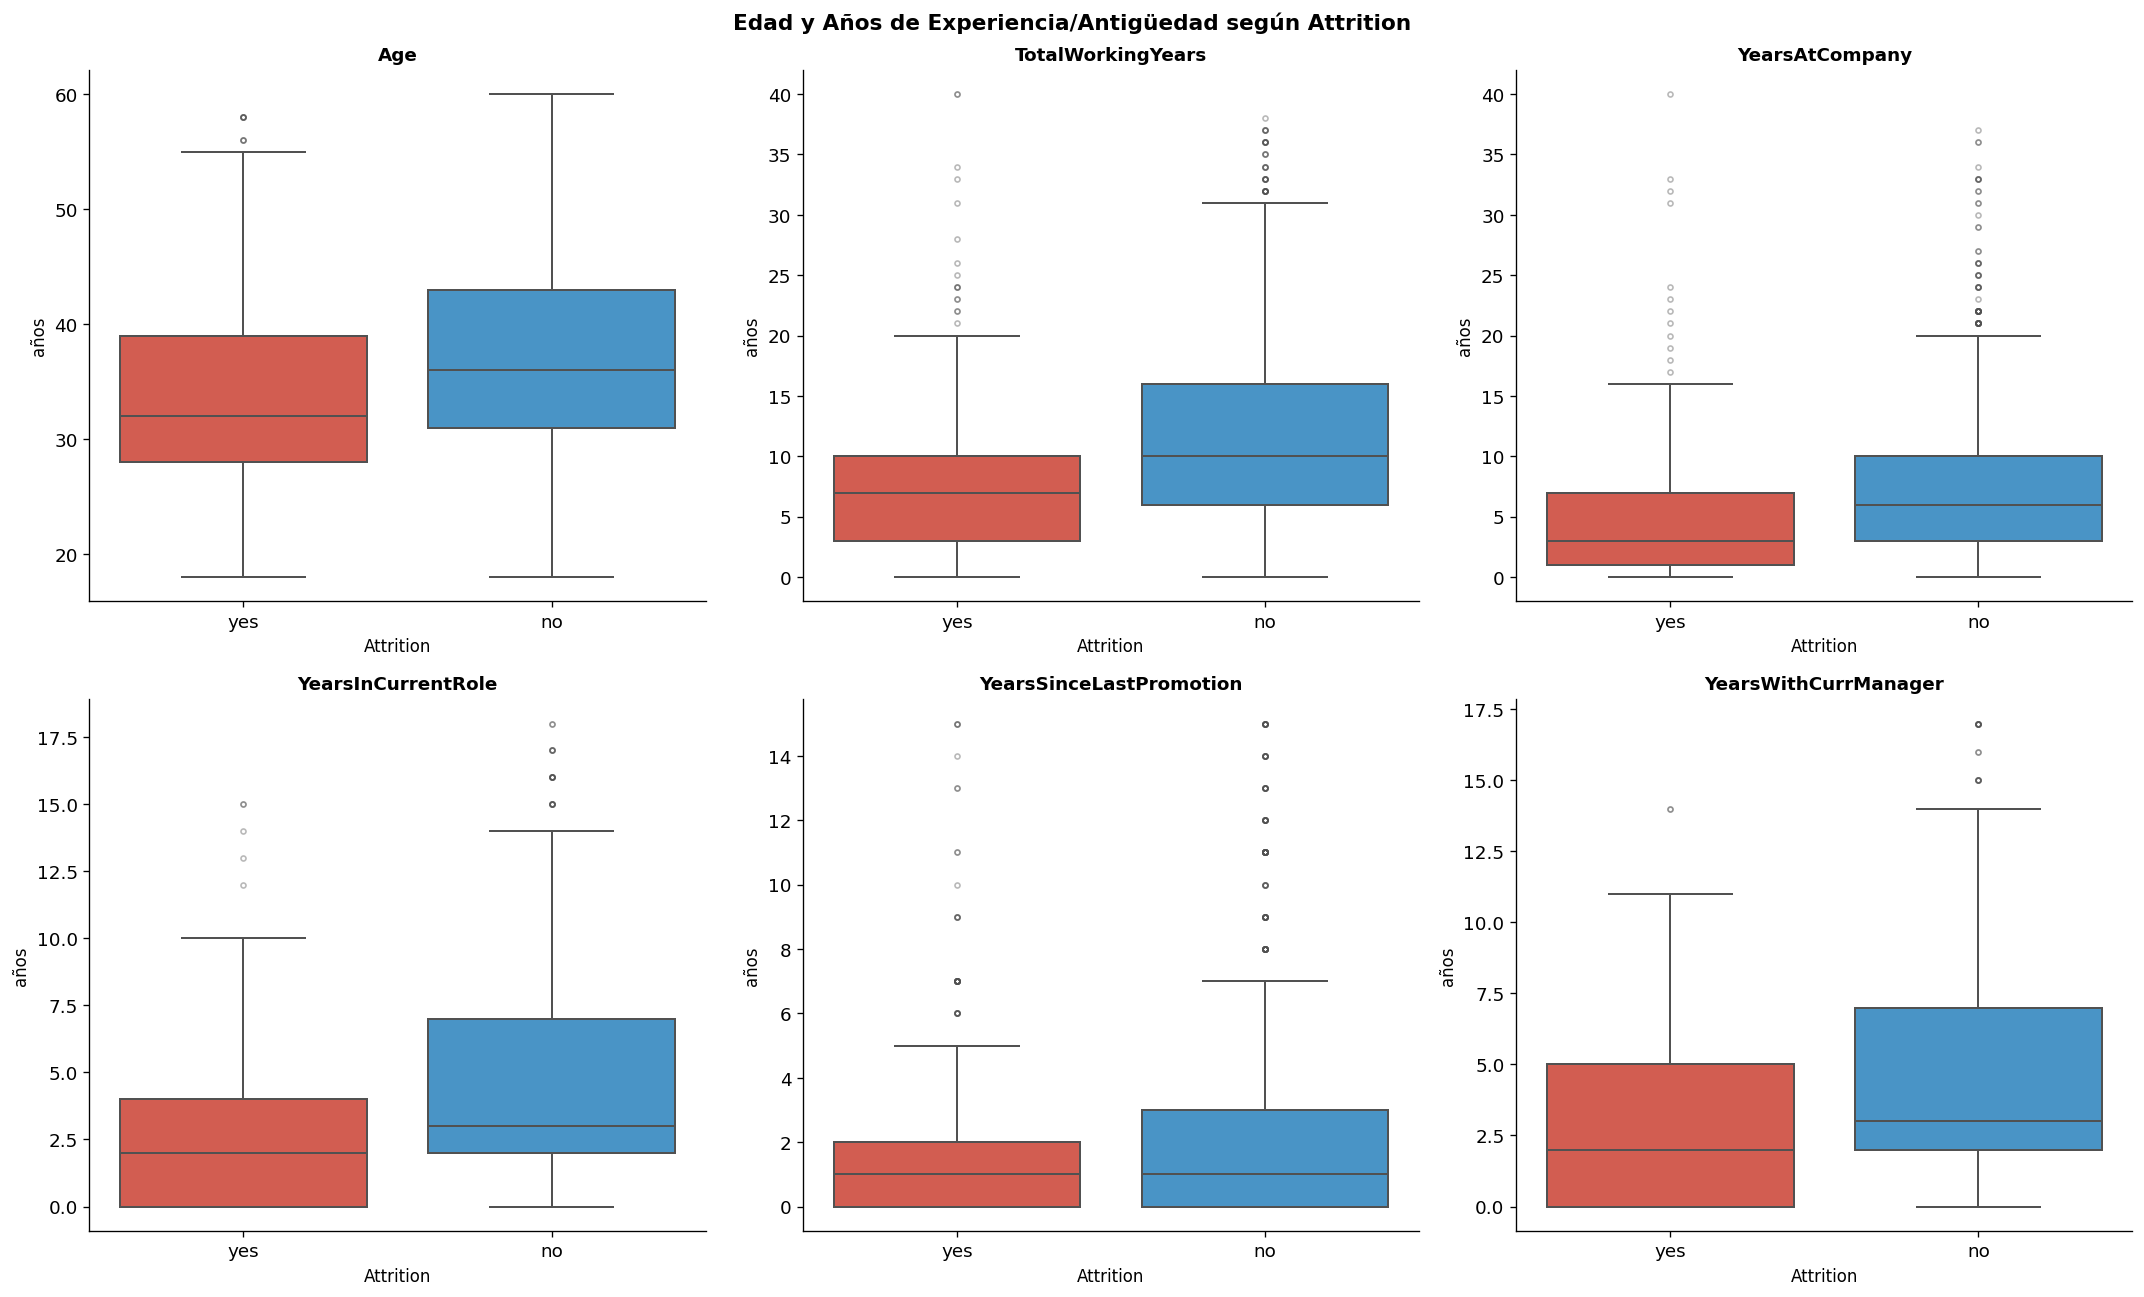

In [18]:
years_vars = ['Age', 'TotalWorkingYears', 'YearsAtCompany',
              'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(years_vars):
    ax = axes[i]
    sns.boxplot(data=df, x='Attrition', y=col, palette=palette,
                order=['yes','no'], ax=ax, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('Attrition', fontsize=10)
    ax.set_ylabel('años', fontsize=10)

fig.suptitle('Edad y Años de Experiencia/Antigüedad según Attrition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_anios_attrition.png', bbox_inches='tight')
plt.show()

### 6.3 MonthlyIncome por Departamento y JobRole

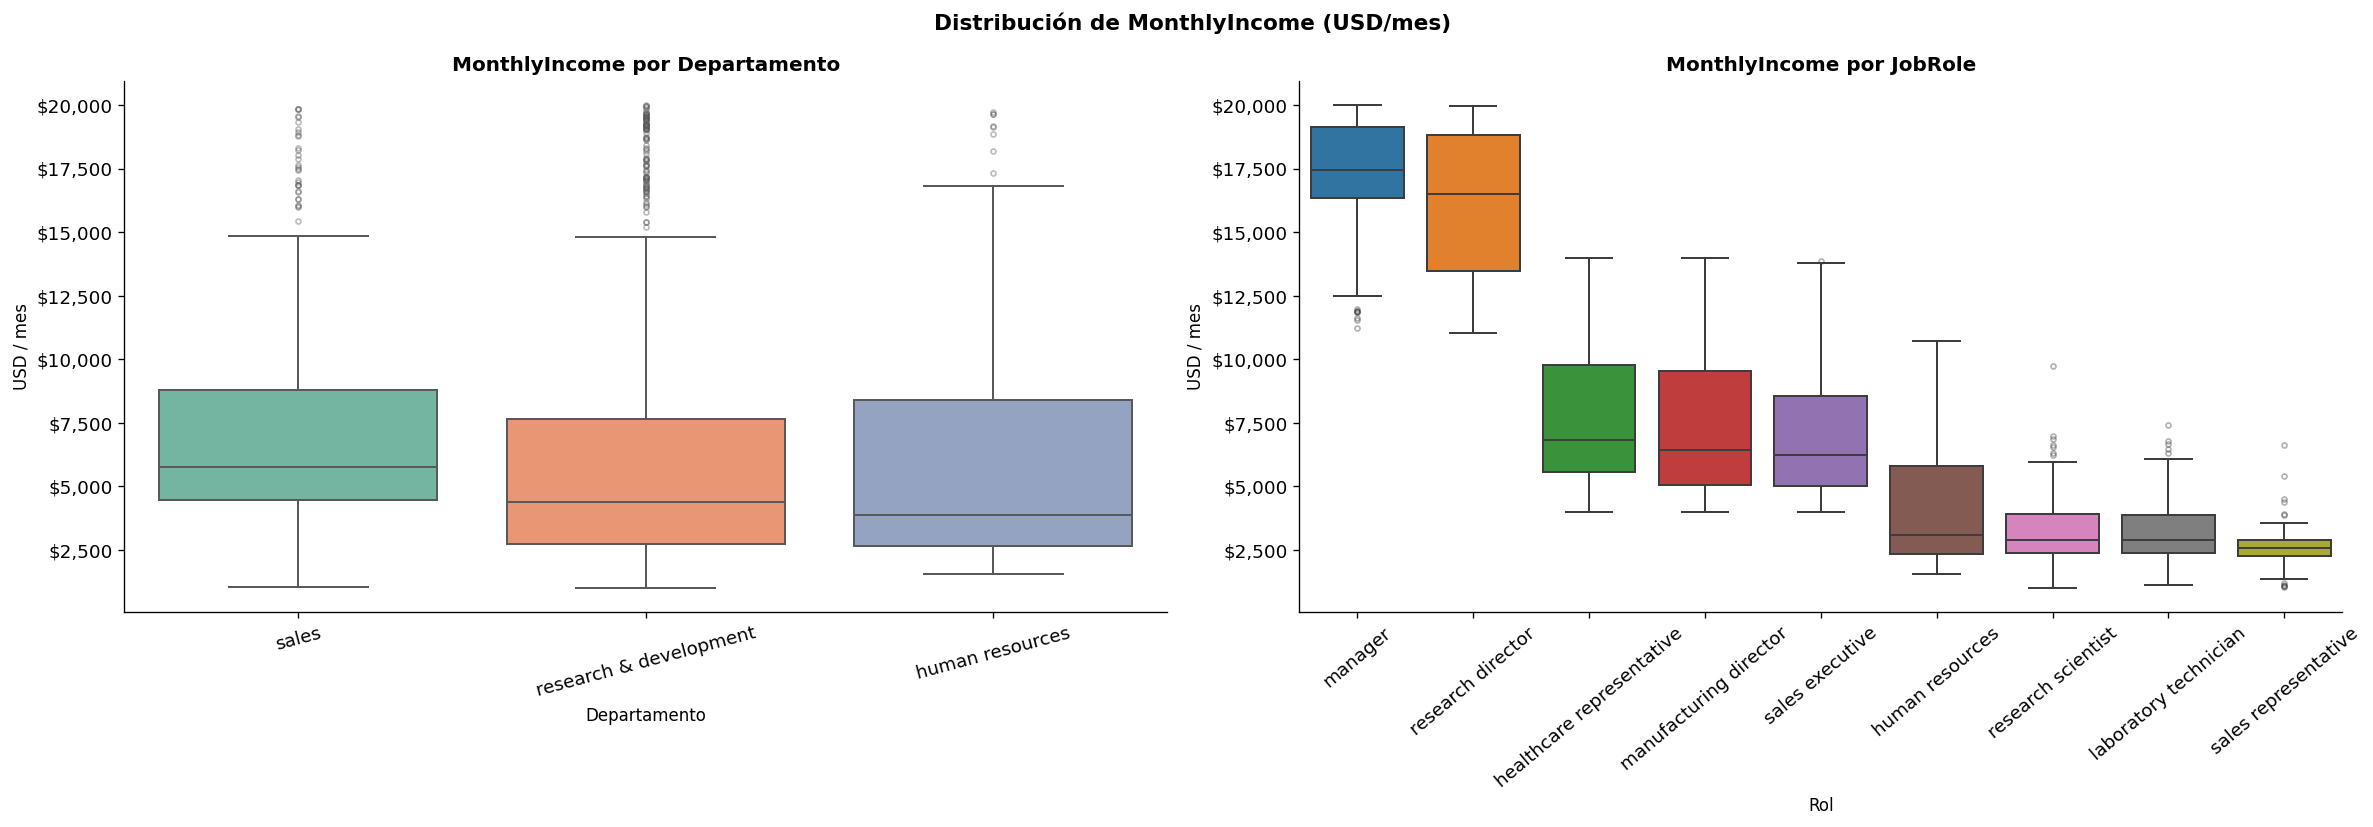

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Por Departamento
order_dept = df.groupby('Department')['MonthlyIncome'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Department', y='MonthlyIncome', order=order_dept,
            palette='Set2', ax=axes[0], linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[0].set_title('MonthlyIncome por Departamento', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Departamento', fontsize=10)
axes[0].set_ylabel('USD / mes', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

# Por JobRole
order_role = df.groupby('JobRole')['MonthlyIncome'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='JobRole', y='MonthlyIncome', order=order_role,
            palette='tab10', ax=axes[1], linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('MonthlyIncome por JobRole', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Rol', fontsize=10)
axes[1].set_ylabel('USD / mes', fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=40)

fig.suptitle('Distribución de MonthlyIncome (USD/mes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_income_dept_role.png', bbox_inches='tight')
plt.show()

### 6.4 MonthlyIncome por JobLevel y PercentSalaryHike por PerformanceRating

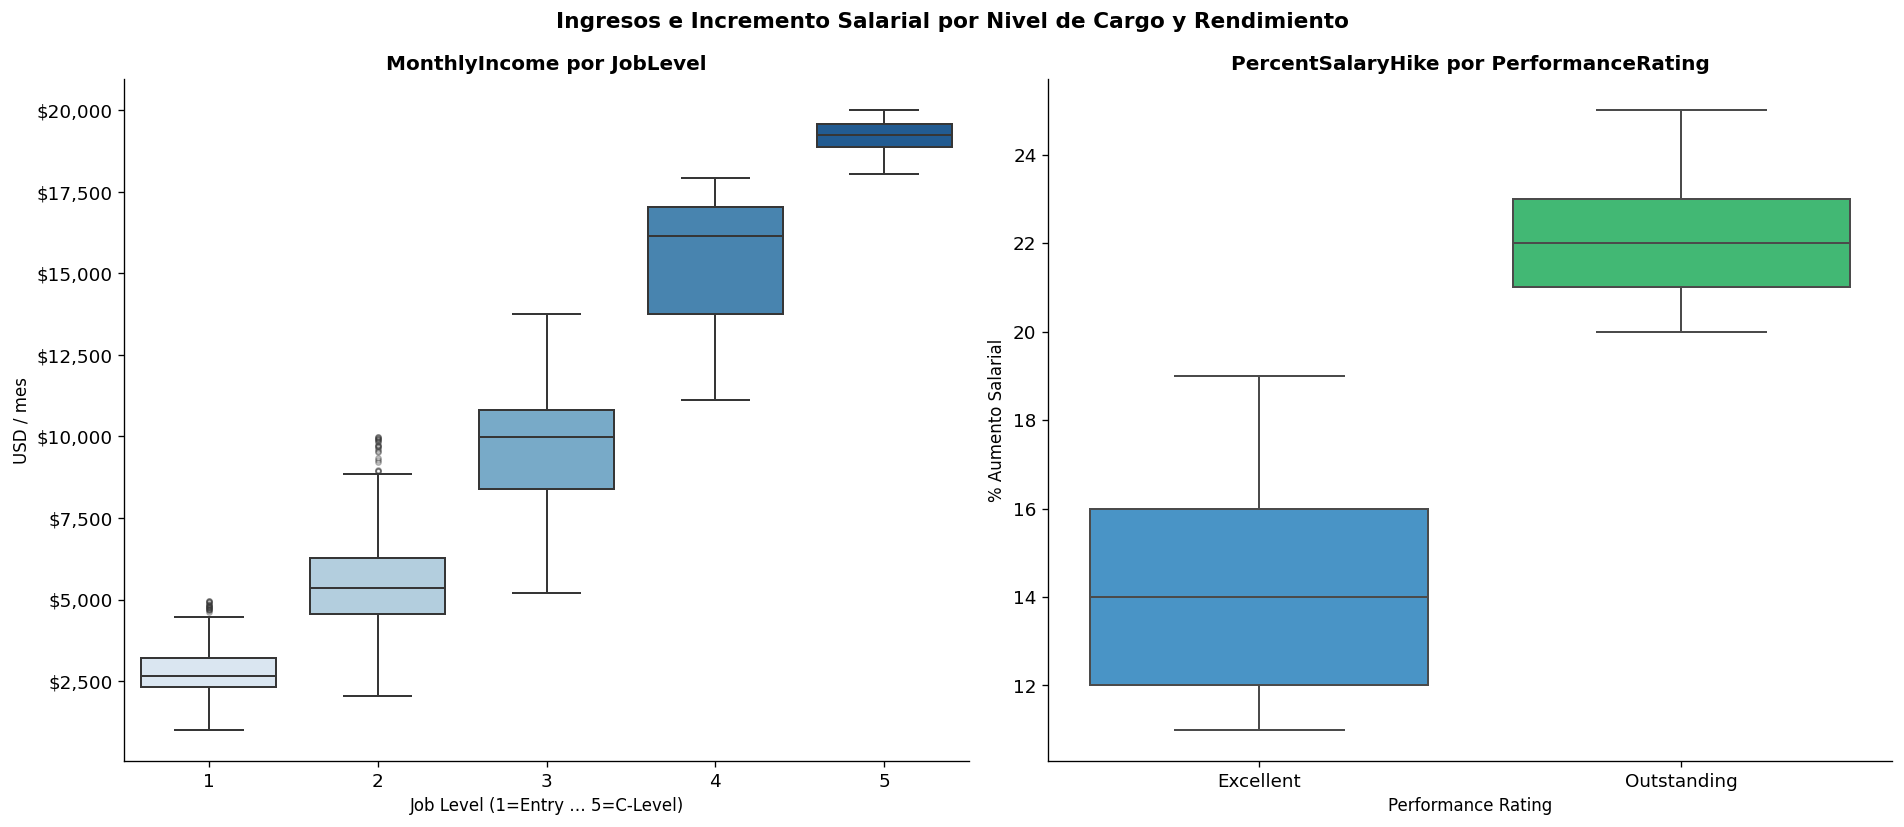

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# MonthlyIncome por JobLevel
sns.boxplot(data=df, x='JobLevel', y='MonthlyIncome',
            palette='Blues', ax=axes[0], linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[0].set_title('MonthlyIncome por JobLevel', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Job Level (1=Entry … 5=C-Level)', fontsize=10)
axes[0].set_ylabel('USD / mes', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# PercentSalaryHike por PerformanceRating
perf_labels = {3: 'Excellent', 4: 'Outstanding'}
df['perf_label'] = df['PerformanceRating'].map(perf_labels)
sns.boxplot(data=df, x='perf_label', y='PercentSalaryHike',
            order=['Excellent', 'Outstanding'],
            palette={'Excellent': '#3498db', 'Outstanding': '#2ecc71'},
            ax=axes[1], linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('PercentSalaryHike por PerformanceRating', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Performance Rating', fontsize=10)
axes[1].set_ylabel('% Aumento Salarial', fontsize=10)

fig.suptitle('Ingresos e Incremento Salarial por Nivel de Cargo y Rendimiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_joblevel_performance.png', bbox_inches='tight')
plt.show()

### 6.5 DistanceFromHome y NumCompaniesWorked por Attrition

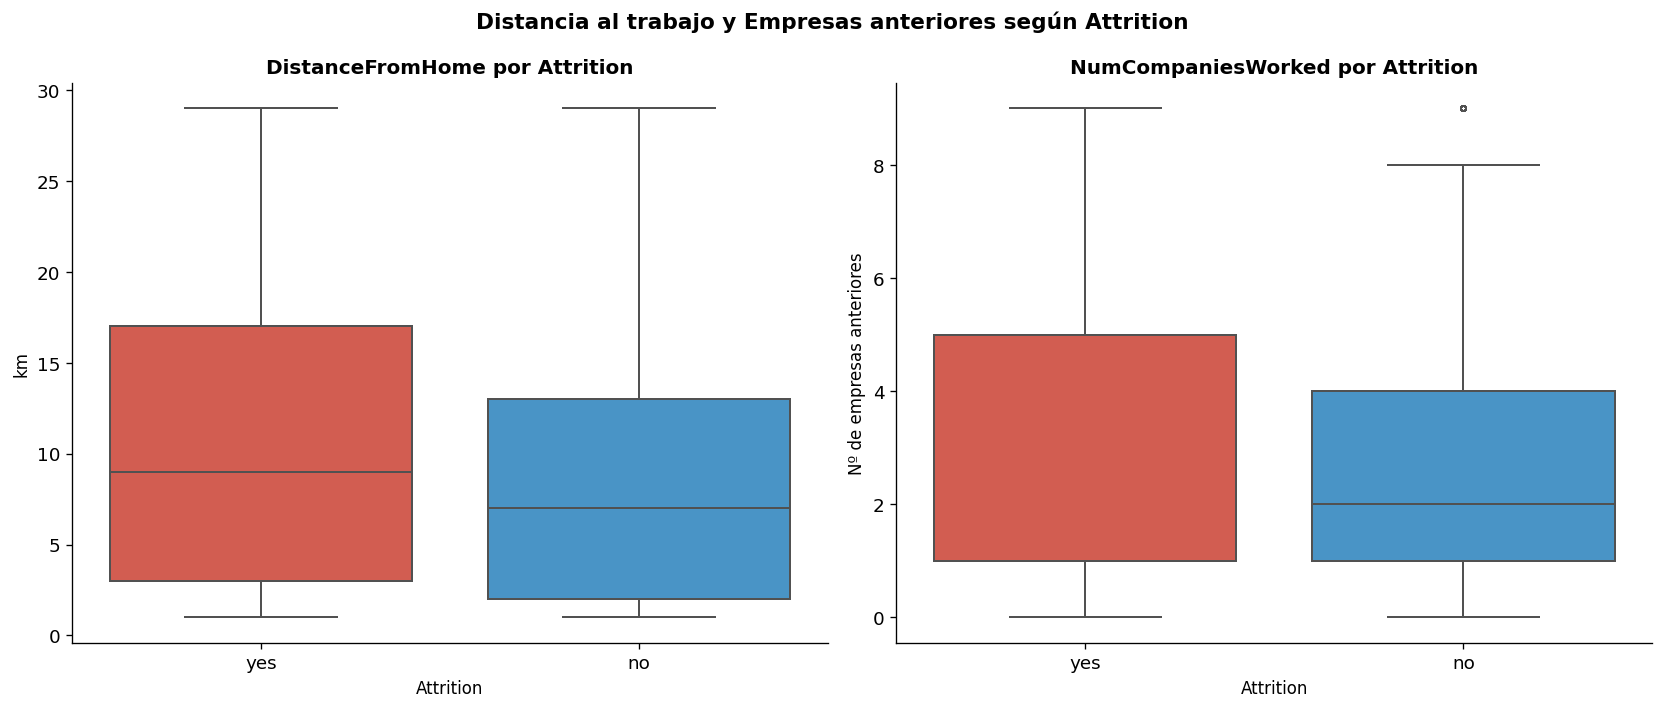

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', palette=palette,
            order=['yes','no'], ax=axes[0], linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[0].set_title('DistanceFromHome por Attrition', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Attrition', fontsize=10)
axes[0].set_ylabel('km', fontsize=10)

sns.boxplot(data=df, x='Attrition', y='NumCompaniesWorked', palette=palette,
            order=['yes','no'], ax=axes[1], linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('NumCompaniesWorked por Attrition', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Attrition', fontsize=10)
axes[1].set_ylabel('Nº de empresas anteriores', fontsize=10)

fig.suptitle('Distancia al trabajo y Empresas anteriores según Attrition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_distancia_empresas.png', bbox_inches='tight')
plt.show()

### 6.6 Satisfacción laboral y work-life balance por Attrition

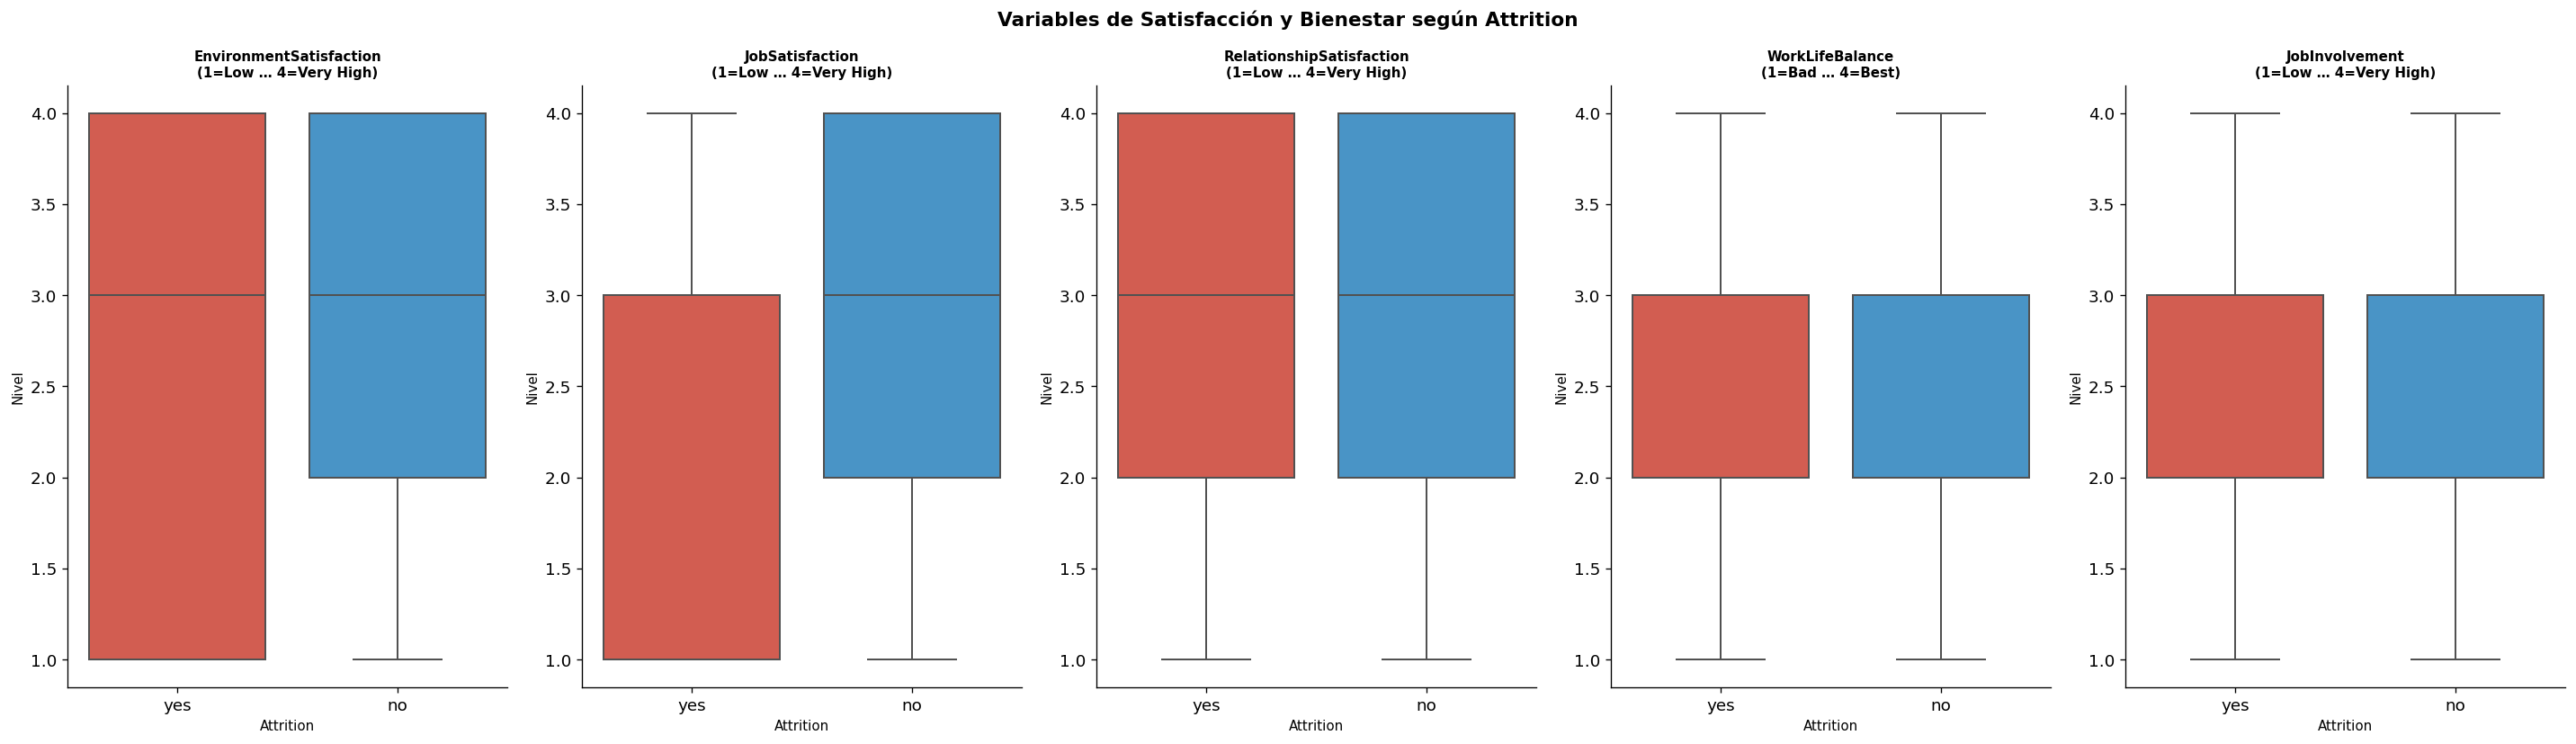

In [22]:
sat_vars = {
    'EnvironmentSatisfaction': '1=Low … 4=Very High',
    'JobSatisfaction':         '1=Low … 4=Very High',
    'RelationshipSatisfaction':'1=Low … 4=Very High',
    'WorkLifeBalance':         '1=Bad … 4=Best',
    'JobInvolvement':          '1=Low … 4=Very High',
}

fig, axes = plt.subplots(1, 5, figsize=(24, 7))
for i, (col, scale) in enumerate(sat_vars.items()):
    ax = axes[i]
    sns.boxplot(data=df, x='Attrition', y=col, palette=palette,
                order=['yes','no'], ax=ax, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(f'{col}\n({scale})', fontweight='bold', fontsize=9)
    ax.set_xlabel('Attrition', fontsize=9)
    ax.set_ylabel('Nivel', fontsize=9)

fig.suptitle('Variables de Satisfacción y Bienestar según Attrition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_satisfaccion_attrition.png', bbox_inches='tight')
plt.show()